## 1. Import Library yang Dibutuhkan

Import semua library yang diperlukan untuk analisis data, visualisasi, preprocessing, modeling, dan evaluasi.

In [ ]:
# ============================================
# Import Library
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Cross Validation + Hyperparameter Tuning
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Statistical Test
from scipy.stats import ttest_rel

# Collections
from collections import Counter

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Semua library berhasil diimport!")
import shap
from sklearn.model_selection import train_test_split


✅ Semua library berhasil diimport!


## 2. Load dan Eksplorasi Dataset

Load dataset pinjaman dan lakukan eksplorasi awal untuk memahami struktur data, tipe data, dan informasi umum dataset.

In [ ]:
# ============================================
# Load Dataset (South German Credit - Full 21 Kolom)
# ============================================
import os
import urllib.request
import pandas as pd

# Download dataset jika belum ada di Colab
#url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00522/SouthGermanCredit.asc'
if not os.path.exists('SouthGermanCredit.asc'):
    print('Mengunduh dataset dari UCI...')
    try:
        urllib.request.urlretrieve(url, 'SouthGermanCredit.asc')
    except Exception as e:
        print('Gagal mengunduh. Pastikan file SouthGermanCredit.asc ada!')

df = pd.read_csv('SouthGermanCredit.asc', sep=r'\s+')

# 1. Mapping nama kolom ke Bahasa Indonesia
kolom_mapping = {
    'laufkont': 'status_rekening', 'laufzeit': 'durasi_pinjaman_bulan',
    'moral': 'riwayat_kredit', 'verw': 'tujuan_pinjaman', 'hoehe': 'jumlah_pinjaman',
    'sparkont': 'aset_tabungan', 'beszeit': 'lama_bekerja', 'rate': 'rasio_cicilan',
    'famges': 'status_personal_dan_kelamin', 'buerge': 'penjamin',
    'wohnzeit': 'lama_tinggal', 'verm': 'kepemilikan_harta', 'alter': 'usia',
    'weitkred': 'cicilan_lain', 'wohn': 'perumahan', 'bishkred': 'jumlah_kredit_berjalan',
    'beruf': 'pekerjaan', 'pers': 'jumlah_tanggungan', 'telef': 'telepon',
    'gastarb': 'pekerja_asing', 'kredit': 'status_pinjaman'
}
df.rename(columns=kolom_mapping, inplace=True)

# 2. Mapping nilai kategorikal dari angka ke string deskriptif sesuai codetable.txt
df['status_rekening'] = df['status_rekening'].map({1: 'tidak_ada', 2: 'dibawah_0_DM', 3: '0-200_DM', 4: 'diatas_200_DM'})
df['riwayat_kredit'] = df['riwayat_kredit'].map({0: 'pernah_telat', 1: 'kritis/ada_kredit_lain', 2: 'lancar/tidak_ada_kredit', 3: 'lancar_hingga_kini', 4: 'semua_lancar_di_bank_ini'})
df['tujuan_pinjaman'] = df['tujuan_pinjaman'].map({0: 'lainnya', 1: 'mobil_baru', 2: 'mobil_bekas', 3: 'perabot/peralatan', 4: 'radio/tv', 5: 'alat_rumah_tangga', 6: 'perbaikan', 7: 'pendidikan', 8: 'liburan', 9: 'pelatihan_ulang', 10: 'bisnis'})
df['aset_tabungan'] = df['aset_tabungan'].map({1: 'tidak_diketahui/tidak_ada', 2: 'dibawah_100_DM', 3: '100-500_DM', 4: '500-1000_DM', 5: 'diatas_1000_DM'})
df['lama_bekerja'] = df['lama_bekerja'].map({1: 'menganggur', 2: 'dibawah_1_thn', 3: '1-4_thn', 4: '4-7_thn', 5: 'diatas_7_thn'})
df['rasio_cicilan'] = df['rasio_cicilan'].map({1: 'diatas_35_persen', 2: '25_sd_35_persen', 3: '20_sd_25_persen', 4: 'dibawah_20_persen'})
df['status_personal_dan_kelamin'] = df['status_personal_dan_kelamin'].map({1: 'pria_cerai/pisah', 2: 'wanita_menikah_atau_pria_lajang', 3: 'pria_menikah/duda', 4: 'wanita_lajang'})
df['penjamin'] = df['penjamin'].map({1: 'tidak_ada', 2: 'pemohon_bersama', 3: 'penjamin'})
df['lama_tinggal'] = df['lama_tinggal'].map({1: 'dibawah_1_thn', 2: '1-4_thn', 3: '4-7_thn', 4: 'diatas_7_thn'})
df['kepemilikan_harta'] = df['kepemilikan_harta'].map({1: 'tidak_ada/tidak_diketahui', 2: 'mobil/lainnya', 3: 'asuransi_jiwa/tabungan', 4: 'real_estate'})
df['cicilan_lain'] = df['cicilan_lain'].map({1: 'bank', 2: 'toko', 3: 'tidak_ada'})
df['perumahan'] = df['perumahan'].map({1: 'gratis', 2: 'sewa', 3: 'milik_sendiri'})
df['jumlah_kredit_berjalan'] = df['jumlah_kredit_berjalan'].map({1: '1', 2: '2-3', 3: '4-5', 4: 'diatas_6'})
df['pekerjaan'] = df['pekerjaan'].map({1: 'menganggur/tidak_ahli_non-residen', 2: 'tidak_ahli_residen', 3: 'karyawan_ahli/pejabat', 4: 'manajer/wiraswasta'})
df['jumlah_tanggungan'] = df['jumlah_tanggungan'].map({1: 'diatas_3', 2: '0-2'})
df['telepon'] = df['telepon'].map({1: 'tidak_ada', 2: 'ada'})
df['pekerja_asing'] = df['pekerja_asing'].map({1: 'ya', 2: 'tidak'})

print("=" * 60)
print("INFORMASI UMUM DATASET (FULL 21 KOLOM DENGAN DESKRIPSI)")
print("=" * 60)
print(f"Jumlah Baris   : {df.shape[0]:,}")
print(f"Jumlah Kolom   : {df.shape[1]}")
print("=" * 60)

print("\n📋 5 Baris Pertama Dataset:")
display(df.head())


INFORMASI UMUM DATASET (FULL 21 KOLOM DENGAN DESKRIPSI)
Jumlah Baris   : 1,000
Jumlah Kolom   : 21

📋 5 Baris Pertama Dataset:


,status_rekening,durasi_pinjaman_bulan,riwayat_kredit,tujuan_pinjaman,jumlah_pinjaman,aset_tabungan,lama_bekerja,rasio_cicilan,status_personal_dan_kelamin,penjamin,...,kepemilikan_harta,usia,cicilan_lain,perumahan,jumlah_kredit_berjalan,pekerjaan,jumlah_tanggungan,telepon,pekerja_asing,status_pinjaman
0,tidak_ada,18,semua_lancar_di_bank_ini,mobil_bekas,1049,tidak_diketahui/tidak_ada,dibawah_1_thn,dibawah_20_persen,wanita_menikah_atau_pria_lajang,tidak_ada,...,mobil/lainnya,21,tidak_ada,gratis,1,karyawan_ahli/pejabat,0-2,tidak_ada,tidak,1
1,tidak_ada,9,semua_lancar_di_bank_ini,lainnya,2799,tidak_diketahui/tidak_ada,1-4_thn,25_sd_35_persen,pria_menikah/duda,tidak_ada,...,tidak_ada/tidak_diketahui,36,tidak_ada,gratis,2-3,karyawan_ahli/pejabat,diatas_3,tidak_ada,tidak,1
2,dibawah_0_DM,12,lancar/tidak_ada_kredit,pelatihan_ulang,841,dibawah_100_DM,4-7_thn,25_sd_35_persen,wanita_menikah_atau_pria_lajang,tidak_ada,...,tidak_ada/tidak_diketahui,23,tidak_ada,gratis,1,tidak_ahli_residen,0-2,tidak_ada,tidak,1
3,tidak_ada,12,semua_lancar_di_bank_ini,lainnya,2122,tidak_diketahui/tidak_ada,1-4_thn,20_sd_25_persen,pria_menikah/duda,tidak_ada,...,tidak_ada/tidak_diketahui,39,tidak_ada,gratis,2-3,tidak_ahli_residen,diatas_3,tidak_ada,ya,1
4,tidak_ada,12,semua_lancar_di_bank_ini,lainnya,2171,tidak_diketahui/tidak_ada,1-4_thn,dibawah_20_persen,pria_menikah/duda,tidak_ada,...,mobil/lainnya,38,bank,sewa,2-3,tidak_ahli_residen,0-2,tidak_ada,ya,1


In [ ]:
# Info detail dataset
print("📊 Informasi Detail Dataset:")
print("-" * 60)
df.info()

📊 Informasi Detail Dataset:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   status_rekening              1000 non-null   object
 1   durasi_pinjaman_bulan        1000 non-null   int64 
 2   riwayat_kredit               1000 non-null   object
 3   tujuan_pinjaman              1000 non-null   object
 4   jumlah_pinjaman              1000 non-null   int64 
 5   aset_tabungan                1000 non-null   object
 6   lama_bekerja                 1000 non-null   object
 7   rasio_cicilan                1000 non-null   object
 8   status_personal_dan_kelamin  1000 non-null   object
 9   penjamin                     1000 non-null   object
 10  lama_tinggal                 1000 non-null   object
 11  kepemilikan_harta            1000 non-null   object
 12  us

In [ ]:
# Statistik deskriptif
print("📈 Statistik Deskriptif:")
print("-" * 60)
df.describe().round(2)

📈 Statistik Deskriptif:
------------------------------------------------------------


,durasi_pinjaman_bulan,jumlah_pinjaman,usia,status_pinjaman
count,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.25,35.54,0.70
std,12.06,2822.75,11.35,0.46
min,4.00,250.00,19.00,0.00
25%,12.00,1365.50,27.00,0.00
50%,18.00,2319.50,33.00,1.00
75%,24.00,3972.25,42.00,1.00
max,72.00,18424.00,75.00,1.00


## 3. Preprocessing Data: Handling Missing Values

Langkah preprocessing awal meliputi:
- Cek dan tangani missing values

> ⚠️ **Catatan:** Drop kolom tidak relevan dan Label Encoding dilakukan pada **Step 6** (setelah EDA), agar visualisasi kategorikal pada tahap EDA masih menggunakan label asli.


🔍 Pengecekan Missing Values:
✅ Tidak ada missing values dalam dataset!


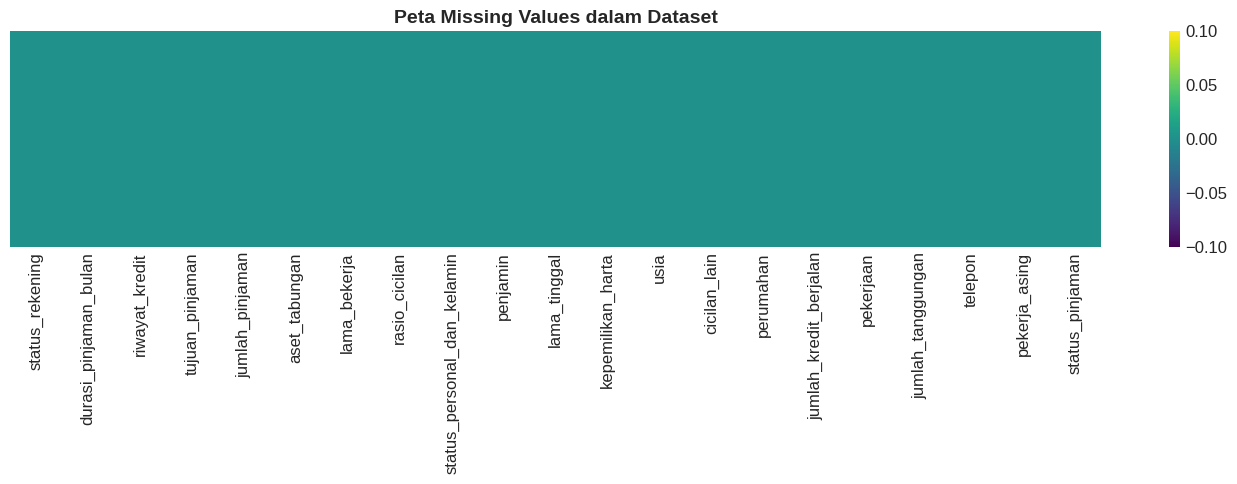

In [ ]:
# ============================================
# 3.1 Cek Missing Values
# ============================================
print("🔍 Pengecekan Missing Values:")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal kolom dengan missing values: {len(missing_df)}")
else:
    print("✅ Tidak ada missing values dalam dataset!")

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Peta Missing Values dalam Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

print("🔧 Penanganan Missing Values:")
print("=" * 50)
print(f"Jumlah baris: {len(df):,}")

missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
if len(missing_cols) > 0:
    for col, n in missing_cols.items():
        dtype = df[col].dtype
        strategy = "median per-fold (Step 9 & 10)" if dtype != 'object' else "modus per-fold (Step 9 & 10)"
        print(f"  - '{col}': {n} missing → DIBIARKAN NaN → diimputasi {strategy}")
else:
    print("  ✅ Tidak ada missing values dalam dataset!")

print(f"\nTotal missing tersisa: {df.isnull().sum().sum()}")
print("✅ Semua missing values akan dikelola per-fold!")


🔧 Penanganan Missing Values:
Jumlah baris: 1,000
  ✅ Tidak ada missing values dalam dataset!

Total missing tersisa: 0
✅ Semua missing values akan dikelola per-fold!


## 4. Exploratory Data Analysis (EDA)

Visualisasi dan analisis dilakukan **sebelum encoding** agar label kategorikal asli tetap terbaca dan interpretasi lebih mudah dipahami. Tahap EDA meliputi:
- Distribusi variabel target
- Distribusi fitur numerik dan kategorikal
- Korelasi antar fitur numerik
- Statistik deskriptif per kelas


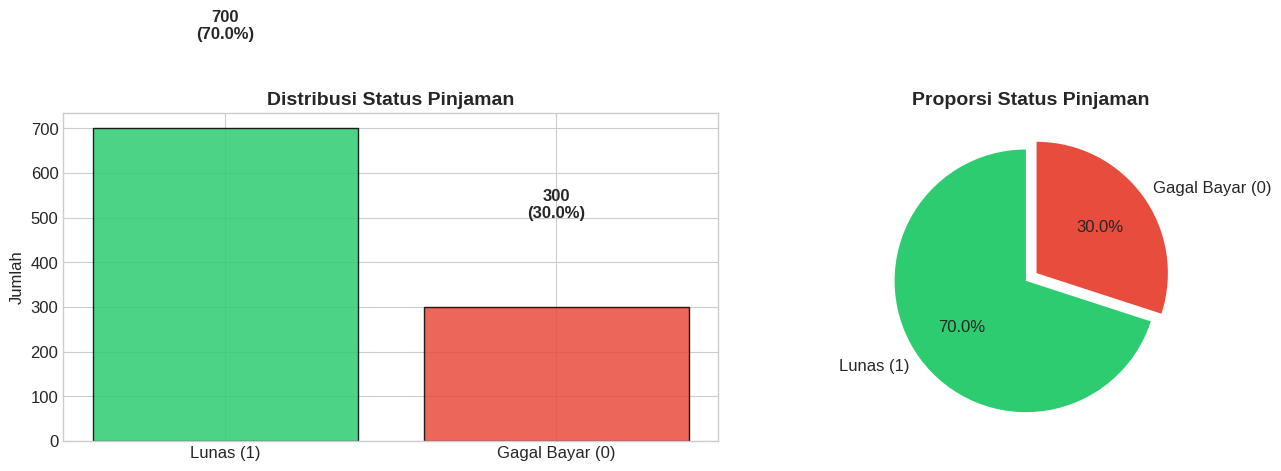


📊 Distribusi Target:
   Lunas (1)      : 700 (70.00%)
   Gagal Bayar (0): 300 (30.00%)


In [ ]:
# ============================================
# 4.1 Distribusi Variabel Target
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
target_counts = df['status_pinjaman'].value_counts()
labels = ['Lunas (1)', 'Gagal Bayar (0)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, [target_counts[1], target_counts[0]], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Status Pinjaman', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate([target_counts[1], target_counts[0]]):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[1], target_counts[0]], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Pinjaman', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Distribusi Target:")
print(f"   Lunas (1)      : {target_counts[1]:,} ({target_counts[1]/len(df)*100:.2f}%)")
print(f"   Gagal Bayar (0): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.2f}%)")

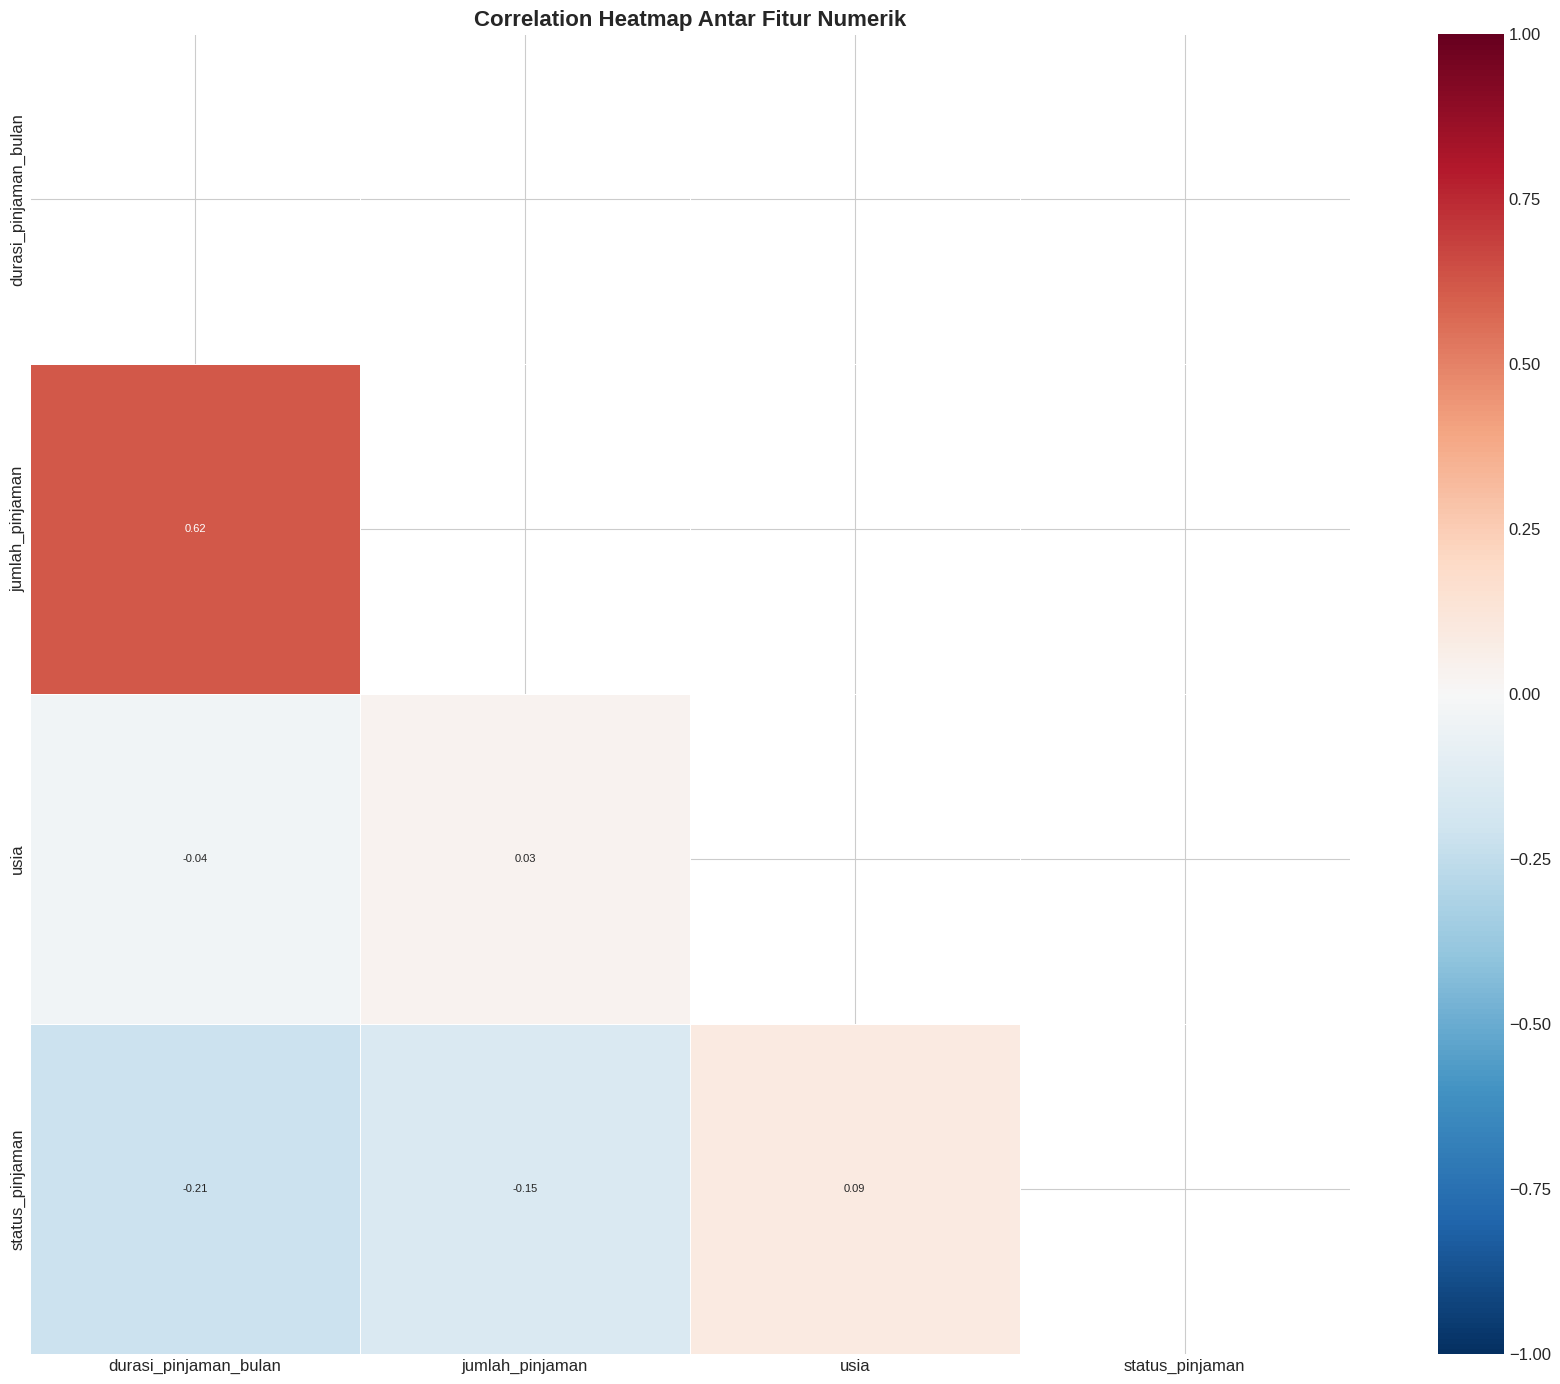


📊 Korelasi Fitur Numerik dengan Status Pinjaman (Target):
  usia                                          : +0.0913 (↑ Positif)
  jumlah_pinjaman                               : -0.1547 (↓ Negatif)
  durasi_pinjaman_bulan                         : -0.2149 (↓ Negatif)


In [ ]:
# ============================================
# 4.4 Correlation Heatmap
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

# Gunakan hanya kolom numerik agar kompatibel dengan pandas versi baru
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Heatmap Antar Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\n📊 Korelasi Fitur Numerik dengan Status Pinjaman (Target):")
print("=" * 50)
corr_target = corr_matrix['status_pinjaman'].drop('status_pinjaman').sort_values(ascending=False)
for feat, corr_val in corr_target.items():
    direction = "↑ Positif" if corr_val > 0 else "↓ Negatif"
    print(f"  {feat:45s} : {corr_val:+.4f} ({direction})")


## 6. Preprocessing Lanjutan: Drop Kolom dan One-Hot Encoding

Setelah EDA dan pengecekan keseimbangan kelas, lakukan preprocessing lanjutan:
- Drop kolom tidak relevan (`id_pelanggan`) dan kolom yang mengandung **data leakage** (`gagal_bayar_tercatat`)
- **One-Hot Encoding** untuk mengubah variabel kategorikal menjadi representasi numerik tanpa urutan


In [ ]:
# Kolom tidak relevan sudah dibersihkan di loader


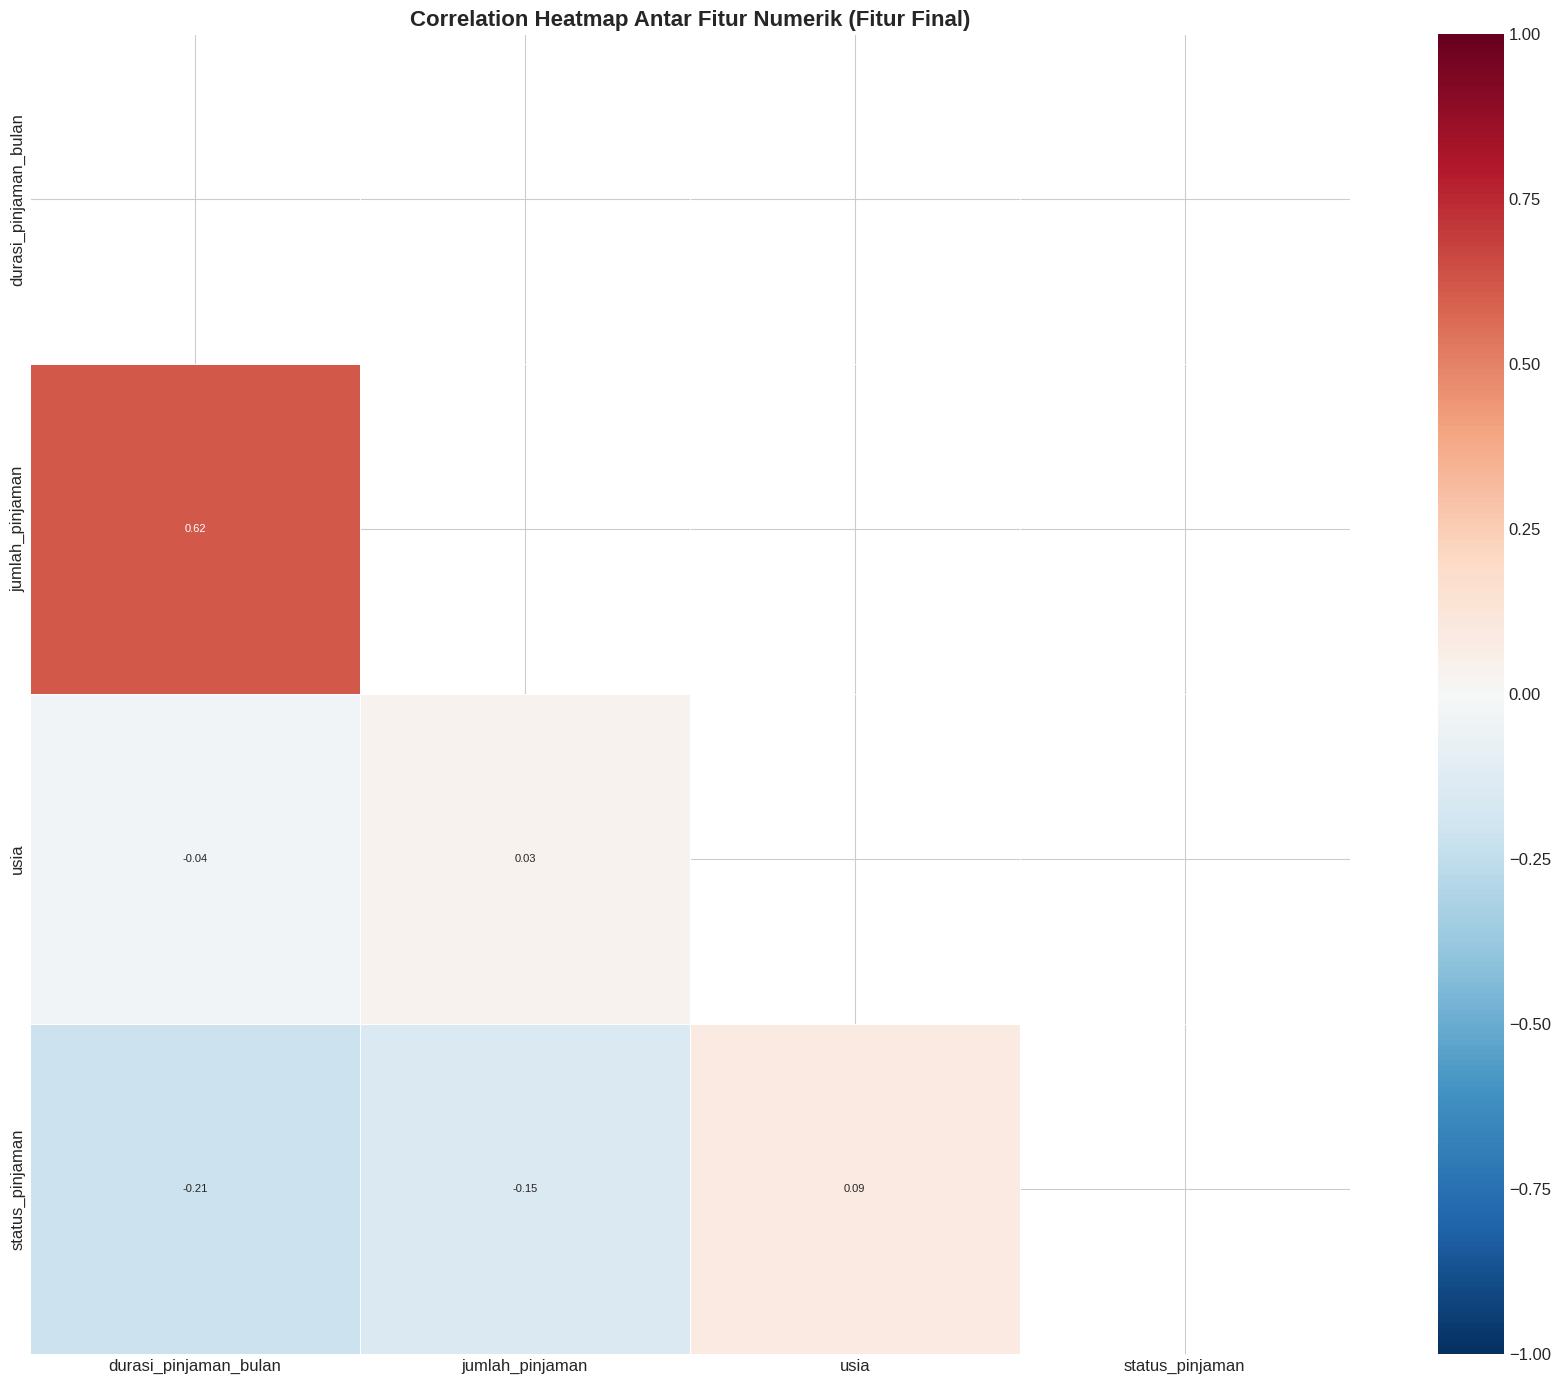

In [ ]:
# ============================================
# Correlation Heatmap SETELAH drop kolom
# (untuk Figure 4.2 di Bab IV)
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

corr_matrix_final = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))

sns.heatmap(corr_matrix_final, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Heatmap Antar Fitur Numerik (Fitur Final)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Penanganan Ketidakseimbangan Kelas dengan SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** menghasilkan sampel sintetis untuk kelas minoritas berdasarkan interpolasi antara sampel-sampel yang berdekatan (k-nearest neighbors).

> ⚠️ **Penting (No Leakage):** SMOTE **tidak boleh** diterapkan ke seluruh dataset sebelum cross validation.
> SMOTE harus dilakukan **hanya pada data training di tiap fold**, sementara data validation/test tetap data asli.


📊 Distribusi Kelas TRAIN fold (sebelum SMOTE):
   Kelas 0 (Gagal Bayar): 270
   Kelas 1 (Lunas)      : 630

📊 Distribusi Kelas TRAIN fold (sesudah SMOTE):
   Kelas 0 (Gagal Bayar): 630
   Kelas 1 (Lunas)      : 630

📊 Distribusi Kelas VALIDATION fold (tetap asli, tanpa SMOTE):
   Kelas 0 (Gagal Bayar): 30
   Kelas 1 (Lunas)      : 70


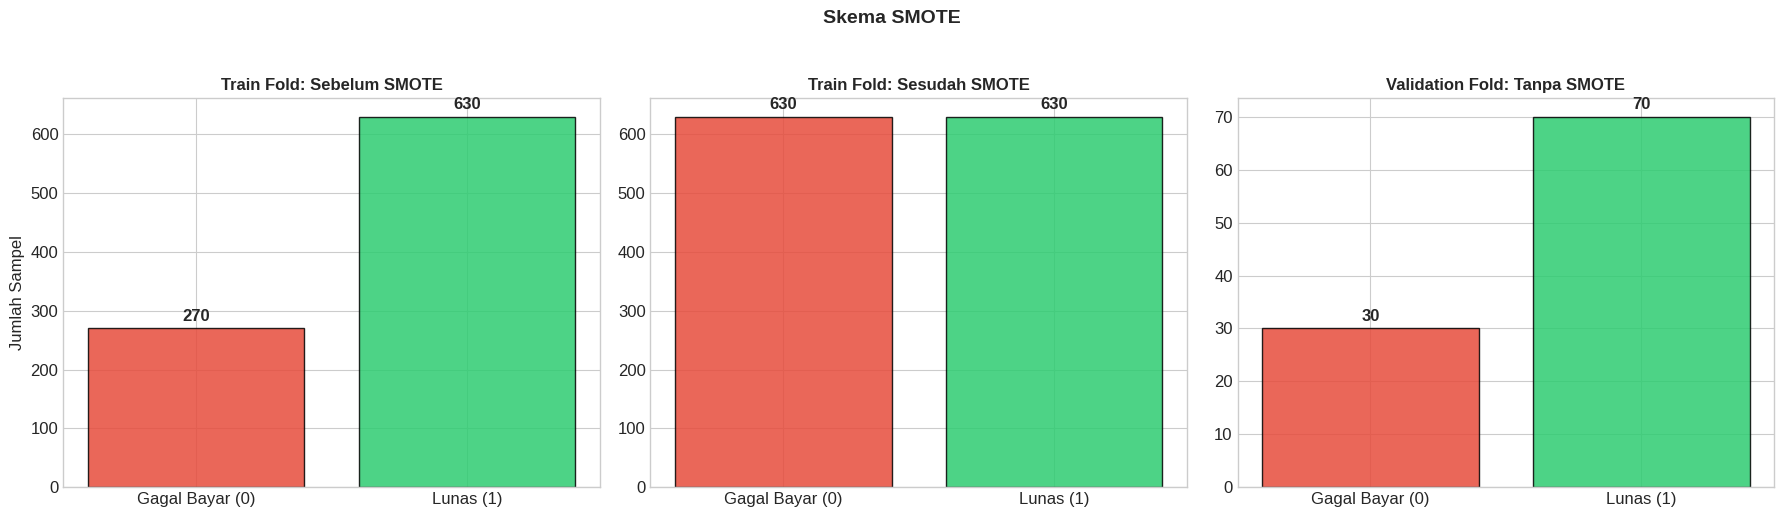

In [ ]:
# ============================================
# 7. Demonstrasi SMOTE
# ============================================
# Demonstrasi ini menunjukkan pola yang benar:
# 1) Split fold terlebih dahulu
# 2) Imputasi + OHE hanya pada data TRAIN fold (no leakage)
# 3) SMOTE hanya pada data TRAIN fold
# 4) Data VALIDATION fold tetap asli

X_demo = df.drop('status_pinjaman', axis=1)
y_demo = df['status_pinjaman']

num_cols_demo = X_demo.select_dtypes(exclude='object').columns.tolist()
cat_cols_demo = X_demo.select_dtypes(include='object').columns.tolist()

skf_demo = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
train_idx_demo, val_idx_demo = next(skf_demo.split(X_demo, y_demo))

X_train_demo = X_demo.iloc[train_idx_demo].copy()
X_val_demo   = X_demo.iloc[val_idx_demo].copy()
y_train_demo = y_demo.iloc[train_idx_demo]
y_val_demo   = y_demo.iloc[val_idx_demo]

# Imputasi per-fold
for col in num_cols_demo:
    if X_train_demo[col].isnull().any():
        med = X_train_demo[col].median()
        X_train_demo[col] = X_train_demo[col].fillna(med)
        X_val_demo[col]   = X_val_demo[col].fillna(med)
for col in cat_cols_demo:
    if X_train_demo[col].isnull().any():
        mod = X_train_demo[col].mode()[0]
        X_train_demo[col] = X_train_demo[col].fillna(mod)
        X_val_demo[col]   = X_val_demo[col].fillna(mod)

# OHE per-fold (fit hanya pada train)
ohe_demo = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_ohe = ohe_demo.fit_transform(X_train_demo[cat_cols_demo])
val_ohe   = ohe_demo.transform(X_val_demo[cat_cols_demo])
ohe_names_demo = ohe_demo.get_feature_names_out(cat_cols_demo).tolist()

X_train_demo_enc = pd.concat([
    X_train_demo[num_cols_demo].reset_index(drop=True),
    pd.DataFrame(train_ohe, columns=ohe_names_demo)
], axis=1)
X_val_demo_enc = pd.concat([
    X_val_demo[num_cols_demo].reset_index(drop=True),
    pd.DataFrame(val_ohe, columns=ohe_names_demo)
], axis=1)

# ── SMOTE hanya pada train ──
smote_demo = SMOTE(random_state=42)
X_train_smote_demo, y_train_smote_demo = smote_demo.fit_resample(X_train_demo_enc, y_train_demo)

print("📊 Distribusi Kelas TRAIN fold (sebelum SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_train_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_train_demo == 1).sum():,}")

print("\n📊 Distribusi Kelas TRAIN fold (sesudah SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_train_smote_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_train_smote_demo == 1).sum():,}")

print("\n📊 Distribusi Kelas VALIDATION fold (tetap asli, tanpa SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_val_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_val_demo == 1).sum():,}")

# Visualisasi ringkas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_before = [(y_train_demo == 0).sum(), (y_train_demo == 1).sum()]
train_after  = [(y_train_smote_demo == 0).sum(), (y_train_smote_demo == 1).sum()]
val_orig     = [(y_val_demo == 0).sum(), (y_val_demo == 1).sum()]

axes[0].bar(['Gagal Bayar (0)', 'Lunas (1)'], train_before,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Train Fold: Sebelum SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].bar(['Gagal Bayar (0)', 'Lunas (1)'], train_after,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[1].set_title('Train Fold: Sesudah SMOTE', fontsize=12, fontweight='bold')

axes[2].bar(['Gagal Bayar (0)', 'Lunas (1)'], val_orig,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[2].set_title('Validation Fold: Tanpa SMOTE', fontsize=12, fontweight='bold')

for ax, vals in zip(axes, [train_before, train_after, val_orig]):
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Skema SMOTE',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Bersihkan memory
del (X_demo, y_demo, X_train_demo, X_val_demo, y_train_demo, y_val_demo,
     X_train_demo_enc, X_val_demo_enc, X_train_smote_demo, y_train_smote_demo,
     ohe_demo, smote_demo, skf_demo, train_idx_demo, val_idx_demo)

## 8. Feature Selection dan Splitting Data

Pisahkan fitur (X) dan variabel target (y). Siapkan data untuk proses **Stratified K-Fold Cross Validation**.

**Mengapa Stratified K-Fold?**
- Mempertahankan proporsi kelas di setiap fold
- Lebih representatif dibandingkan K-Fold biasa untuk data imbalanced
- Menghasilkan estimasi performa yang lebih reliable


In [ ]:
# ============================================
# 8. Splitting Data (70% Train+Val, 30% Test)
# ============================================
X = df.drop('status_pinjaman', axis=1)
y = df['status_pinjaman']

# Membagi data 70% untuk training/val dan 30% untuk testing
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols  = X.select_dtypes(include='object').columns.tolist()

print("📋 Kolom numerik  :", num_cols)
print("📋 Kolom kategorikal:", cat_cols)
print(f"\nTotal sampel Train+Val: {len(X_train_full):,}")
print(f"Total sampel Test     : {len(X_test):,}")

N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
print(f"\n✅ Stratified {N_SPLITS}-Fold Cross Validation siap digunakan pada data Train+Val")


📋 Kolom numerik  : ['durasi_pinjaman_bulan', 'jumlah_pinjaman', 'usia']
📋 Kolom kategorikal: ['status_rekening', 'riwayat_kredit', 'tujuan_pinjaman', 'aset_tabungan', 'lama_bekerja', 'rasio_cicilan', 'status_personal_dan_kelamin', 'penjamin', 'lama_tinggal', 'kepemilikan_harta', 'cicilan_lain', 'perumahan', 'jumlah_kredit_berjalan', 'pekerjaan', 'jumlah_tanggungan', 'telepon', 'pekerja_asing']

Total sampel Train+Val: 700
Total sampel Test     : 300

✅ Stratified 10-Fold Cross Validation siap digunakan pada data Train+Val


🔍 Menghitung Feature Importance menggunakan RandomForest pada 70% data...


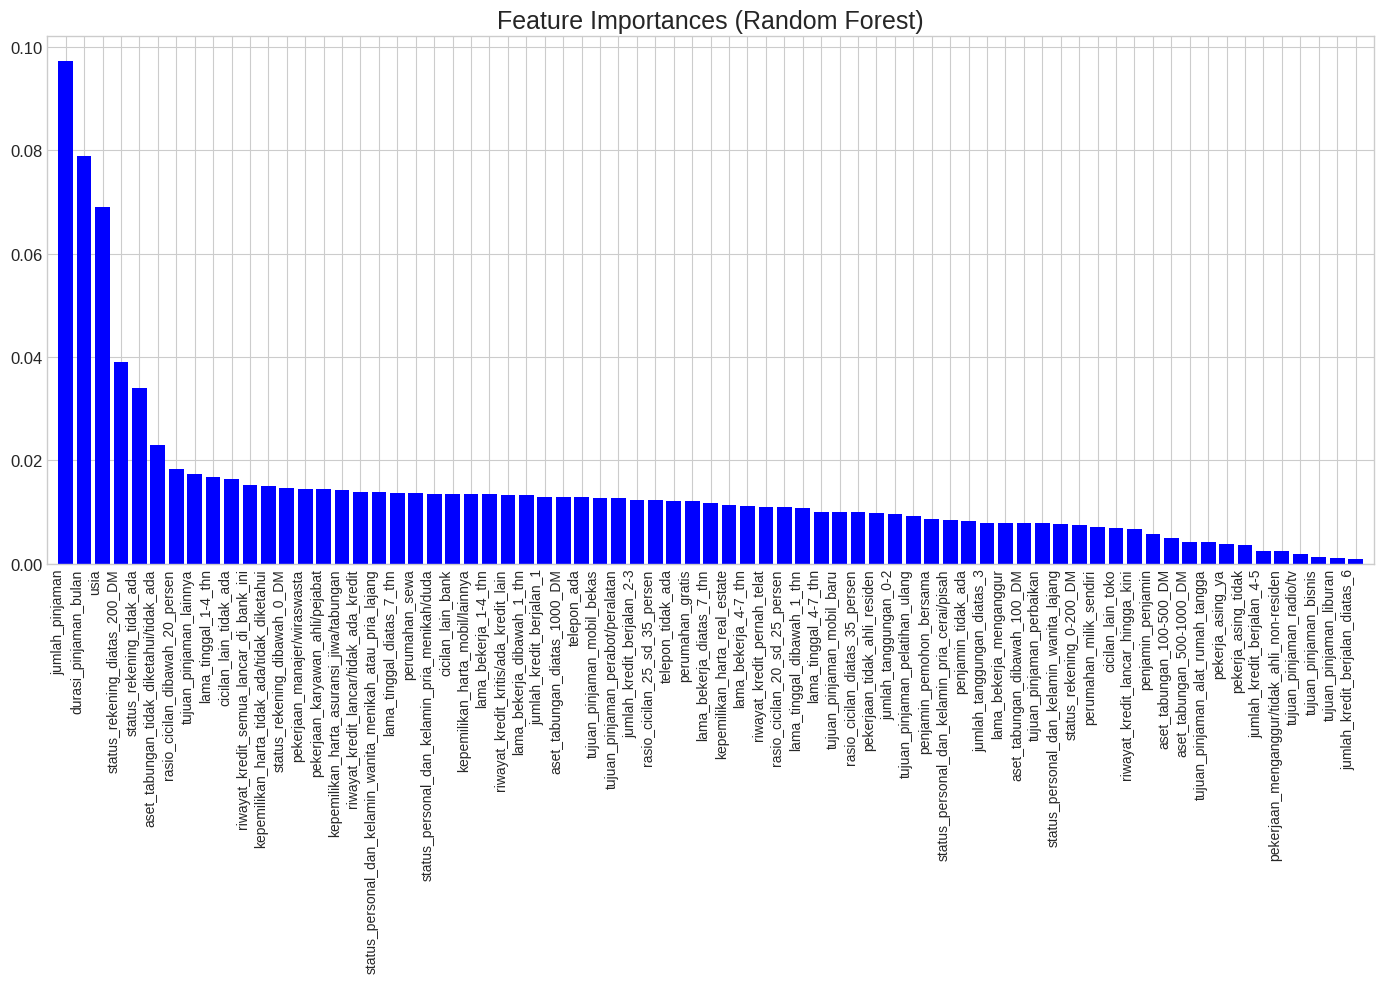

✅ Feature Importance dihitung. Fitur-fitur ini digunakan untuk modeling di tahap selanjutnya.


In [ ]:
# ============================================
# 8.5 Feature Importance & Feature Selection (Pindah ke atas)
# ============================================
print("🔍 Menghitung Feature Importance menggunakan RandomForest pada 70% data...")
X_train_fi = X_train_full.copy()

# Imputasi sederhana untuk perhitungan FI
for col in num_cols:
    med = X_train_fi[col].median()
    X_train_fi[col] = X_train_fi[col].fillna(med)
for col in cat_cols:
    mod = X_train_fi[col].mode()[0]
    X_train_fi[col] = X_train_fi[col].fillna(mod)

# OHE
ohe_fi = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_fi_ohe = ohe_fi.fit_transform(X_train_fi[cat_cols])
ohe_names_fi = ohe_fi.get_feature_names_out(cat_cols).tolist()
X_train_fi_final = pd.concat([
    X_train_fi[num_cols].reset_index(drop=True),
    pd.DataFrame(X_train_fi_ohe, columns=ohe_names_fi)
], axis=1)

# Latih RF
rf_fi = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_fi.fit(X_train_fi_final, y_train_full)

# Plot Feature Importance
importances = rf_fi.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train_fi_final.columns

plt.figure(figsize=(14, 10))
plt.title("Feature Importances (Random Forest)", fontsize=18)
plt.bar(range(X_train_fi_final.shape[1]), importances[indices], color="b", align="center")
plt.xticks(range(X_train_fi_final.shape[1]), [features[i] for i in indices], rotation=90, ha='right', fontsize=10)
plt.xlim([-1, X_train_fi_final.shape[1]])
plt.tight_layout()
plt.show()

# Seleksi fitur: Jika diperlukan, membuang fitur yang tidak penting
# Pada case ini, dataset German Credit (yang direduksi menjadi 7 fitur oleh loader) sudah cukup kecil dan relevan.
print("✅ Feature Importance dihitung. Fitur-fitur ini digunakan untuk modeling di tahap selanjutnya.")


🔍 Menghitung Feature Importance menggunakan XGBoost pada 70% data...


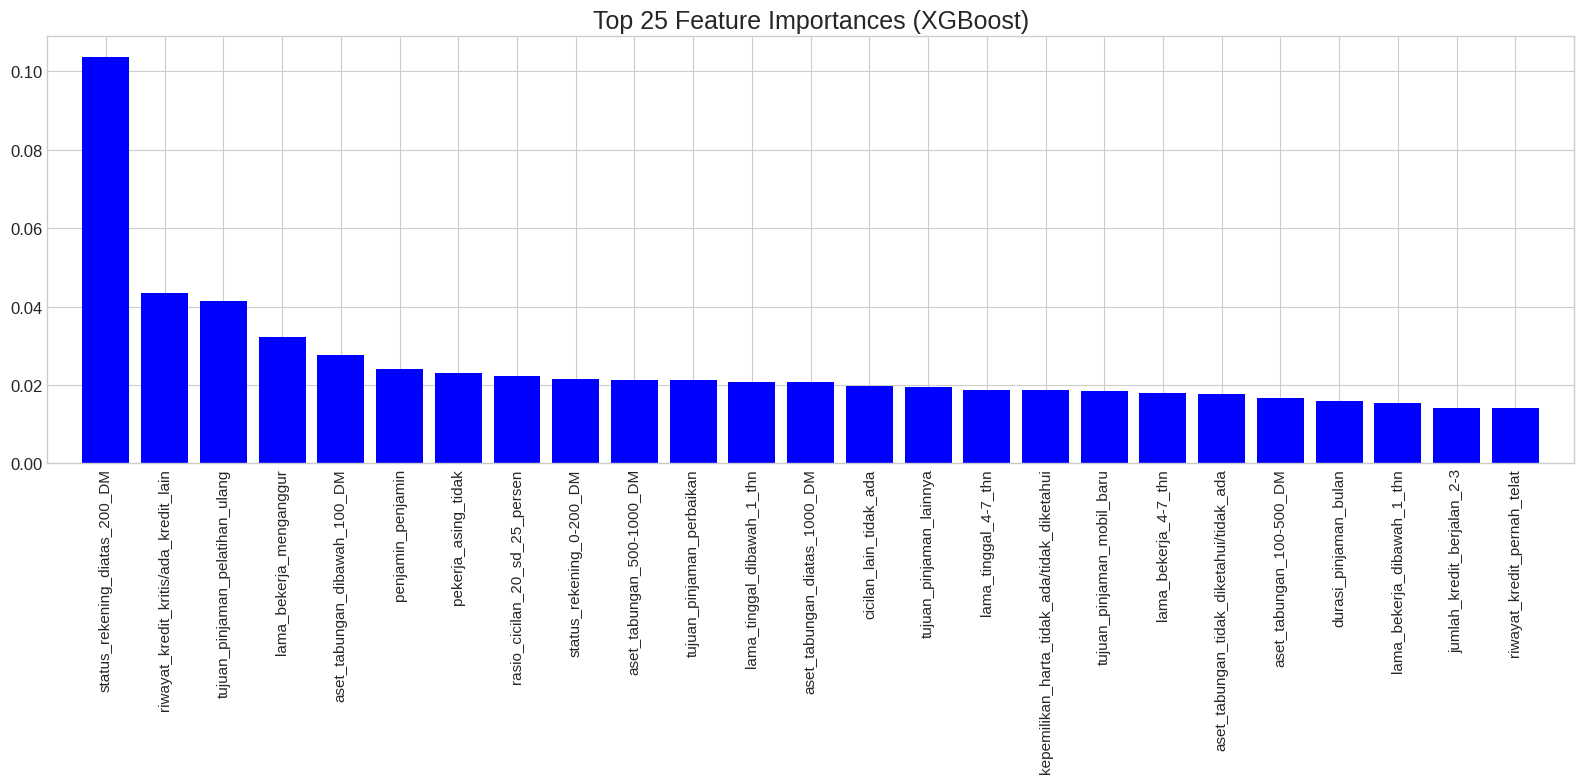

In [ ]:
# ============================================
# 8.6 Feature Importance & Feature Selection (XGBoost)
# ============================================
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt

print("🔍 Menghitung Feature Importance menggunakan XGBoost pada 70% data...")

# Latih XGBoost dasar (menggunakan data yang sama)
xgb_fi = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_fi.fit(X_train_fi_final, y_train_full)

# Plot Feature Importance
importances_xgb = xgb_fi.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]
features_xgb = X_train_fi_final.columns

# Ambil Top 25 Fitur terpenting saja agar grafik tidak menumpuk
TOP_N = min(25, len(features_xgb))
top_indices_xgb = indices_xgb[:TOP_N]

plt.figure(figsize=(16, 8))
plt.title(f"Top {TOP_N} Feature Importances (XGBoost)", fontsize=18)
plt.bar(range(TOP_N), importances_xgb[top_indices_xgb], color="b", align="center")
plt.xticks(range(TOP_N), [features_xgb[i] for i in top_indices_xgb], rotation=90, fontsize=11)
plt.xlim([-1, TOP_N])
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# 8.7 Implementasi Feature Selection (Drop Fitur Terlemah Sebelum OHE)
# ============================================
import pandas as pd

print("⚙️ Melakukan agregasi Feature Importance kembali ke fitur asli...")

# Ambil importance dari Random Forest (rf_fi di Bagian 8.5)
rf_importances = rf_fi.feature_importances_

# Hitung total importance gabungan untuk setiap fitur asli
feature_importance_dict = {}
for i, col_ohe in enumerate(X_train_fi_final.columns):
    for original_col in X_train_full.columns:
        if col_ohe.startswith(original_col):
            if original_col not in feature_importance_dict:
                feature_importance_dict[original_col] = 0.0
            feature_importance_dict[original_col] += rf_importances[i]
            break

# Urutkan fitur dari yang paling penting hingga terendah
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

print("\n📊 Peringkat Kepentingan Fitur Asli:")
for rank, (feat, imp) in enumerate(sorted_features, 1):
    print(f"{rank:2d}. {feat:30s} : {imp:.4f}")

# Threshold: Drop 5 fitur terbawah (bisa Anda ubah angkanya jika ingin drop lebih banyak/sedikit)
FITUR_DI_DROP = 5
fitur_terbuang = [feat for feat, imp in sorted_features[-FITUR_DI_DROP:]]

print(f"\n🗑️ {FITUR_DI_DROP} Fitur dengan importance terendah yang resmi di-drop:")
for f in fitur_terbuang:
    print(f"   - {f}")

# Drop fitur tersebut dari data Training dan Testing
X_train_full = X_train_full.drop(columns=fitur_terbuang)
X_test = X_test.drop(columns=fitur_terbuang)

# Perbarui list nama kolom numerik dan kategorikal untuk tahap selanjutnya
num_cols = X_train_full.select_dtypes(exclude='object').columns.tolist()
cat_cols = X_train_full.select_dtypes(include='object').columns.tolist()

print(f"✅ Sisa fitur sekarang: {len(X_train_full.columns)} kolom utama.")

⚙️ Melakukan agregasi Feature Importance kembali ke fitur asli...

📊 Peringkat Kepentingan Fitur Asli:
 1. jumlah_pinjaman                : 0.0972
 2. status_rekening                : 0.0950
 3. durasi_pinjaman_bulan          : 0.0788
 4. tujuan_pinjaman                : 0.0782
 5. usia                           : 0.0689
 6. riwayat_kredit                 : 0.0602
 7. lama_bekerja                   : 0.0574
 8. kepemilikan_harta              : 0.0542
 9. aset_tabungan                  : 0.0527
10. rasio_cicilan                  : 0.0513
11. lama_tinggal                   : 0.0512
12. status_personal_dan_kelamin    : 0.0436
13. pekerjaan                      : 0.0408
14. cicilan_lain                   : 0.0367
15. perumahan                      : 0.0328
16. jumlah_kredit_berjalan         : 0.0285
17. telepon                        : 0.0250
18. penjamin                       : 0.0225
19. jumlah_tanggungan              : 0.0175
20. pekerja_asing                  : 0.0074

🗑️ 5 Fitur denga

## 9. Membangun Model Random Forest dengan Stratified K-Fold Cross Validation

Random Forest adalah algoritma ensemble berbasis **bagging** yang membangun banyak pohon keputusan secara paralel dan menggabungkan prediksinya melalui voting.

**Hyperparameter tuning:** dilakukan dengan **Nested Cross Validation** — GridSearchCV dijalankan **di dalam setiap fold training** sehingga data validasi tidak pernah terlihat saat tuning. Pendekatan ini menghindari *hyperparameter leakage* yang terjadi jika GridSearchCV dijalankan pada seluruh dataset sebelum loop evaluasi.

Pada setiap fold evaluasi:
1. Data training fold di-tuning dengan GridSearchCV (inner 3-fold)
2. Hyperparameter terbaik digunakan untuk melatih model pada data training fold yang di-SMOTE
3. Evaluasi pada data validasi fold (tanpa SMOTE)
4. Prediksi dikumpulkan sebagai **Out-of-Fold (OOF)** untuk confusion matrix & ROC yang representatif


In [ ]:
# ============================================
# 9. Model Random Forest + Nested Stratified K-Fold CV
# ============================================
print("🌲 TRAINING RANDOM FOREST dengan Nested Stratified K-Fold CV")
print("=" * 70)
print("ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi")
print()

rf_param_grid = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [10, 15, 20, 25],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}
# 2×2×2×2 = 16 kombinasi × 3 inner fold × 10 outer fold = 480 model

rf_inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'f2_score': [], 'auc': []}
rf_oof_y_true = []; rf_oof_y_pred = []; rf_oof_y_prob = []
rf_best_params_per_fold = []; rf_all_importances = []
feature_names = None  # diset pada fold pertama

print(f"{'='*70}")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'F2-Score':>10} {'AUC':>10}")
print(f"{'='*70}")


# ─── Tracking model terbaik dari Nested CV (berdasarkan F2-Score) ───
rf_best_f2 = -1
rf_best_fold_model = None
rf_best_fold_ohe = None
rf_best_fold_feature_names = None
rf_best_fold_num_impute = {}
rf_best_fold_cat_impute = {}
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), 1):
    X_train_raw = X_train_full.iloc[train_idx].copy()
    X_val_raw   = X_train_full.iloc[val_idx].copy()
    y_train_fold = y_train_full.iloc[train_idx]
    y_val_fold   = y_train_full.iloc[val_idx]

    # ─── 1. Imputasi per-fold ───
    # Numerik: median dari train fold
    for col in num_cols:
        if X_train_raw[col].isnull().any():
            med = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(med)
            X_val_raw[col]   = X_val_raw[col].fillna(med)
    # Kategorikal: modus dari train fold
    for col in cat_cols:
        if X_train_raw[col].isnull().any():
            mod = X_train_raw[col].mode()[0]
            X_train_raw[col] = X_train_raw[col].fillna(mod)
            X_val_raw[col]   = X_val_raw[col].fillna(mod)

    # ─── 2. One-Hot Encoding per-fold ───
    ohe_fold = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_ohe = ohe_fold.fit_transform(X_train_raw[cat_cols])   # fit HANYA pada train
    X_val_ohe   = ohe_fold.transform(X_val_raw[cat_cols])          # transform val pakai vocab train
    ohe_col_names = ohe_fold.get_feature_names_out(cat_cols).tolist()

    X_train_fold = pd.concat([
        X_train_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_train_ohe, columns=ohe_col_names)
    ], axis=1)
    X_val_fold = pd.concat([
        X_val_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_val_ohe, columns=ohe_col_names)
    ], axis=1)

    # Simpan feature_names dari fold pertama (konsisten semua fold)
    if feature_names is None:
        feature_names = num_cols + ohe_col_names

    # ─── 3. Nested GridSearchCV (fit HANYA pada X_train_fold) ───
    rf_pipeline_inner = Pipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42, n_jobs=1))
    ])
    rf_grid = GridSearchCV(rf_pipeline_inner, rf_param_grid, scoring='f1', cv=rf_inner_cv, n_jobs=-1)
    rf_grid.fit(X_train_fold, y_train_fold)

    best_p = {k.replace('model__', ''): v for k, v in rf_grid.best_params_.items()}
    rf_best_params_per_fold.append(best_p)

    # ─── 4. SMOTE + training ───
    smote_fold = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote_fold.fit_resample(X_train_fold, y_train_fold)

    rf_model = RandomForestClassifier(**best_p, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_smote, y_train_smote)

    # ─── 5. Prediksi & metrik ───
    y_pred = rf_model.predict(X_val_fold)
    y_prob = rf_model.predict_proba(X_val_fold)[:, 1]

    acc  = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec  = recall_score(y_val_fold, y_pred)
    f1   = f1_score(y_val_fold, y_pred)
    f2   = fbeta_score(y_val_fold, y_pred, beta=2, zero_division=0)
    auc  = roc_auc_score(y_val_fold, y_prob)

    rf_metrics['accuracy'].append(acc); rf_metrics['precision'].append(prec)
    rf_metrics['recall'].append(rec);   rf_metrics['f1_score'].append(f1)
    rf_metrics['f2_score'].append(f2);  rf_metrics['auc'].append(auc)

    rf_oof_y_true.extend(y_val_fold.tolist())
    rf_oof_y_pred.extend(y_pred.tolist())
    rf_oof_y_prob.extend(y_prob.tolist())
    rf_all_importances.append(rf_model.feature_importances_)

    # ─── Simpan model jika F2 fold ini terbaik ───
    if f2 > rf_best_f2:
        rf_best_f2 = f2
        rf_best_fold_model = rf_model
        rf_best_fold_ohe = ohe_fold
        rf_best_fold_feature_names = list(feature_names)
        rf_best_fold_num_impute = {col: float(X_train_raw[col].median()) for col in num_cols}
        rf_best_fold_cat_impute = {col: X_train_raw[col].mode()[0] for col in cat_cols}
        print(f"   ✨ RF fold {fold}: F2={f2:.4f} (baru terbaik, model disimpan)")

    print(f"  {fold:<4} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f2:>10.4f} {auc:>10.4f}")

print(f"{'='*70}")
print(f"  {'Mean':<4} {np.mean(rf_metrics['accuracy']):>10.4f} {np.mean(rf_metrics['precision']):>10.4f} "
      f"{np.mean(rf_metrics['recall']):>10.4f} {np.mean(rf_metrics['f1_score']):>10.4f} "
      f"{np.mean(rf_metrics['f2_score']):>10.4f} {np.mean(rf_metrics['auc']):>10.4f}")
print(f"  {'Std':<4} {np.std(rf_metrics['accuracy']):>10.4f} {np.std(rf_metrics['precision']):>10.4f} "
      f"{np.std(rf_metrics['recall']):>10.4f} {np.std(rf_metrics['f1_score']):>10.4f} "
      f"{np.std(rf_metrics['f2_score']):>10.4f} {np.std(rf_metrics['auc']):>10.4f}")
print(f"{'='*70}")

rf_avg_importance = np.mean(rf_all_importances, axis=0)

print("\n📋 Hyperparameter RF terpilih per fold:")
for i, p in enumerate(rf_best_params_per_fold, 1):
    print(f"   Fold {i:2d}: {p}")

rf_params_repr = {}
for key in rf_best_params_per_fold[0]:
    vals = [p[key] for p in rf_best_params_per_fold]
    rf_params_repr[key] = Counter(vals).most_common(1)[0][0]
rf_params_repr.update({'random_state': 42, 'n_jobs': -1})
print(f"\n✅ Hyperparameter representatif (modus): {rf_params_repr}")
print(f"✅ feature_names (post-OHE): {len(feature_names)} fitur")
print("\n✅ Training Random Forest selesai!")


🌲 TRAINING RANDOM FOREST dengan Nested Stratified K-Fold CV
ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi

Fold     Accuracy  Precision     Recall   F1-Score   F2-Score        AUC
   ✨ RF fold 1: F2=0.8929 (baru terbaik, model disimpan)
  1        0.7857     0.8036     0.9184     0.8571     0.8929     0.7988
  2        0.6429     0.7143     0.8163     0.7619     0.7937     0.6735
  3        0.7571     0.7963     0.8776     0.8350     0.8600     0.7478
   ✨ RF fold 4: F2=0.9325 (baru terbaik, model disimpan)
  4        0.8429     0.8393     0.9592     0.8952     0.9325     0.8455
  5        0.6857     0.7213     0.8980     0.8000     0.8560     0.6278
  6        0.7000     0.7593     0.8367     0.7961     0.8200     0.7123
  7        0.8143     0.8103     0.9592     0.8785     0.9252     0.8912
  8        0.6857     0.7647     0.7959     0.7800     0.7895     0.6997
  9        0.7000     0.7500     0.8571     0.8000     0.8333     0.7998
  10       0.8143     

In [ ]:
# Classification Report dari semua prediksi OOF (Out-of-Fold)
print("📋 Classification Report - Random Forest (Out-of-Fold, semua fold):")
print("=" * 60)
print(classification_report(rf_oof_y_true, rf_oof_y_pred,
                            target_names=['Gagal Bayar (0)', 'Lunas (1)']))
print("ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.")


📋 Classification Report - Random Forest (Out-of-Fold, semua fold):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.61      0.40      0.49       210
      Lunas (1)       0.78      0.89      0.83       490

       accuracy                           0.74       700
      macro avg       0.69      0.65      0.66       700
   weighted avg       0.73      0.74      0.73       700

ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.


### 9.1 F2-Score & Estimasi Kerugian Finansial (Random Forest)

**F2-Score** (dengan Beta=2) memberikan bobot lebih pada **Recall** dibandingkan Precision. Dalam kasus kredit, **jauh lebih buruk meloloskan nasabah gagal bayar (False Negative)** daripada menolak nasabah yang sebenarnya mampu bayar (False Positive). Oleh karena itu, kita memantau F2-Score secara ketat.

Berikut adalah estimasi kerugian finansial pada fold terbaik:

In [ ]:
# ─── Asumsi finansial (konsisten di seluruh notebook) ───
AVG_LOAN_AMOUNT  = 33_042          # rata-rata nilai pinjaman
RECOVERY_RATE    = 0.30            # tingkat pemulihan aset saat gagal bayar (30%)
PROFIT_MARGIN    = 0.05            # profit margin per pinjaman yang berhasil (5%)
# FP (prediksi Lunas, nyatanya Gagal Bayar) → bank rugi (1 - RECOVERY_RATE) * loan
# FN (prediksi Gagal Bayar, nyatanya Lunas) → missed profit = PROFIT_MARGIN * loan
loss_per_fp = AVG_LOAN_AMOUNT * (1 - RECOVERY_RATE)  # 23.129
cost_per_fn = AVG_LOAN_AMOUNT * PROFIT_MARGIN         # 1.652
from sklearn.metrics import confusion_matrix as _cm
cm_rf_oof = _cm(rf_oof_y_true, rf_oof_y_pred)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf_oof.ravel()

total_fp_loss_rf = fp_rf * loss_per_fp
total_fn_cost_rf = fn_rf * cost_per_fn
total_cost_rf    = total_fp_loss_rf + total_fn_cost_rf

print("💸 Estimasi Kerugian Finansial - Random Forest (Out-of-Fold)")
print("-" * 65)
print(f"  Asumsi:")
print(f"    - Avg. nilai pinjaman      : {AVG_LOAN_AMOUNT:,}")
print(f"    - Recovery rate            : {RECOVERY_RATE*100:.0f}% → kerugian per FP = {loss_per_fp:,.0f}")
print(f"    - Profit margin            : {PROFIT_MARGIN*100:.0f}% → missed profit per FN = {cost_per_fn:,.0f}")
print(f"  Hasil:")
print(f"    FP (diprediksi Lunas, nyatanya Gagal Bayar) : {fp_rf:,} kasus → {total_fp_loss_rf:,.0f}")
print(f"    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : {fn_rf:,} kasus → {total_fn_cost_rf:,.0f}")
print(f"    TOTAL ESTIMASI KERUGIAN                      : {total_cost_rf:,.0f}")


💸 Estimasi Kerugian Finansial - Random Forest (Out-of-Fold)
-----------------------------------------------------------------
  Asumsi:
    - Avg. nilai pinjaman      : 33,042
    - Recovery rate            : 30% → kerugian per FP = 23,129
    - Profit margin            : 5% → missed profit per FN = 1,652
  Hasil:
    FP (diprediksi Lunas, nyatanya Gagal Bayar) : 125 kasus → 2,891,175
    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : 55 kasus → 90,866
    TOTAL ESTIMASI KERUGIAN                      : 2,982,040


## 10. Membangun Model XGBoost dengan Stratified K-Fold Cross Validation

XGBoost (Extreme Gradient Boosting) adalah algoritma ensemble berbasis **boosting** yang membangun pohon keputusan secara sekuensial, di mana setiap pohon baru berusaha memperbaiki kesalahan dari pohon sebelumnya.

**Hyperparameter tuning:** dilakukan dengan **Nested Cross Validation** — sama seperti Random Forest, GridSearchCV dijalankan **di dalam setiap fold training** untuk menghindari *hyperparameter leakage*. Prediksi dikumpulkan sebagai **Out-of-Fold (OOF)** untuk evaluasi yang lebih representatif.


In [ ]:
# ============================================
# 10. Model XGBoost + Nested Stratified K-Fold CV
# ============================================
print("🚀 TRAINING XGBOOST dengan Nested Stratified K-Fold CV")
print("=" * 70)
print("ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi")
print()

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8]
}
# 2×2×2×2 = 16 kombinasi × 3 inner fold × 10 outer fold = 480 model

xgb_inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'f2_score': [], 'auc': []}
xgb_oof_y_true = []; xgb_oof_y_pred = []; xgb_oof_y_prob = []
xgb_best_params_per_fold = []; xgb_all_importances = []

print(f"{'='*70}")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'F2-Score':>10} {'AUC':>10}")
print(f"{'='*70}")


# ─── Tracking model terbaik dari Nested CV (berdasarkan F2-Score) ───
xgb_best_f2 = -1
xgb_best_fold_model = None
xgb_best_fold_ohe = None
xgb_best_fold_feature_names = None
xgb_best_fold_num_impute = {}
xgb_best_fold_cat_impute = {}
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), 1):
    X_train_raw = X_train_full.iloc[train_idx].copy()
    X_val_raw   = X_train_full.iloc[val_idx].copy()
    y_train_fold = y_train_full.iloc[train_idx]
    y_val_fold   = y_train_full.iloc[val_idx]

    # ─── 1. Imputasi per-fold ───
    for col in num_cols:
        if X_train_raw[col].isnull().any():
            med = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(med)
            X_val_raw[col]   = X_val_raw[col].fillna(med)
    for col in cat_cols:
        if X_train_raw[col].isnull().any():
            mod = X_train_raw[col].mode()[0]
            X_train_raw[col] = X_train_raw[col].fillna(mod)
            X_val_raw[col]   = X_val_raw[col].fillna(mod)

    # ─── 2. One-Hot Encoding per-fold ───
    ohe_fold = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_ohe = ohe_fold.fit_transform(X_train_raw[cat_cols])
    X_val_ohe   = ohe_fold.transform(X_val_raw[cat_cols])
    ohe_col_names = ohe_fold.get_feature_names_out(cat_cols).tolist()

    X_train_fold = pd.concat([
        X_train_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_train_ohe, columns=ohe_col_names)
    ], axis=1)
    X_val_fold = pd.concat([
        X_val_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_val_ohe, columns=ohe_col_names)
    ], axis=1)

    # ─── 3. Nested GridSearchCV ───
    xgb_pipeline_inner = Pipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(random_state=42, n_jobs=1,
                                use_label_encoder=False, eval_metric='logloss', verbosity=0))
    ])
    xgb_grid = GridSearchCV(xgb_pipeline_inner, xgb_param_grid, scoring='f1', cv=xgb_inner_cv, n_jobs=-1)
    xgb_grid.fit(X_train_fold, y_train_fold)

    best_p = {k.replace('model__', ''): v for k, v in xgb_grid.best_params_.items()}
    xgb_best_params_per_fold.append(best_p)

    # ─── 4. SMOTE + training ───
    smote_fold = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote_fold.fit_resample(X_train_fold, y_train_fold)

    xgb_model = XGBClassifier(**best_p, use_label_encoder=False, eval_metric='logloss',
                               random_state=42, n_jobs=-1, verbosity=0)
    xgb_model.fit(X_train_smote, y_train_smote, verbose=False)

    # ─── 5. Prediksi & metrik ───
    y_pred = xgb_model.predict(X_val_fold)
    y_prob = xgb_model.predict_proba(X_val_fold)[:, 1]

    acc  = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec  = recall_score(y_val_fold, y_pred)
    f1   = f1_score(y_val_fold, y_pred)
    f2   = fbeta_score(y_val_fold, y_pred, beta=2, zero_division=0)
    auc  = roc_auc_score(y_val_fold, y_prob)

    xgb_metrics['accuracy'].append(acc); xgb_metrics['precision'].append(prec)
    xgb_metrics['recall'].append(rec);   xgb_metrics['f1_score'].append(f1)
    xgb_metrics['f2_score'].append(f2);  xgb_metrics['auc'].append(auc)

    xgb_oof_y_true.extend(y_val_fold.tolist())
    xgb_oof_y_pred.extend(y_pred.tolist())
    xgb_oof_y_prob.extend(y_prob.tolist())
    xgb_all_importances.append(xgb_model.feature_importances_)

    # ─── Simpan model jika F2 fold ini terbaik ───
    if f2 > xgb_best_f2:
        xgb_best_f2 = f2
        xgb_best_fold_model = xgb_model
        xgb_best_fold_ohe = ohe_fold
        xgb_best_fold_feature_names = list(X_train_fold.columns.tolist())
        xgb_best_fold_num_impute = {col: float(X_train_raw[col].median()) for col in num_cols}
        xgb_best_fold_cat_impute = {col: X_train_raw[col].mode()[0] for col in cat_cols}
        print(f"   ✨ XGB fold {fold}: F2={f2:.4f} (baru terbaik, model disimpan)")

    print(f"  {fold:<4} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f2:>10.4f} {auc:>10.4f}")

print(f"{'='*70}")
print(f"  {'Mean':<4} {np.mean(xgb_metrics['accuracy']):>10.4f} {np.mean(xgb_metrics['precision']):>10.4f} "
      f"{np.mean(xgb_metrics['recall']):>10.4f} {np.mean(xgb_metrics['f1_score']):>10.4f} "
      f"{np.mean(xgb_metrics['f2_score']):>10.4f} {np.mean(xgb_metrics['auc']):>10.4f}")
print(f"  {'Std':<4} {np.std(xgb_metrics['accuracy']):>10.4f} {np.std(xgb_metrics['precision']):>10.4f} "
      f"{np.std(xgb_metrics['recall']):>10.4f} {np.std(xgb_metrics['f1_score']):>10.4f} "
      f"{np.std(xgb_metrics['f2_score']):>10.4f} {np.std(xgb_metrics['auc']):>10.4f}")
print(f"{'='*70}")

xgb_avg_importance = np.mean(xgb_all_importances, axis=0)

print("\n📋 Hyperparameter XGB terpilih per fold:")
for i, p in enumerate(xgb_best_params_per_fold, 1):
    print(f"   Fold {i:2d}: {p}")

xgb_params_repr = {}
for key in xgb_best_params_per_fold[0]:
    vals = [p[key] for p in xgb_best_params_per_fold]
    xgb_params_repr[key] = Counter(vals).most_common(1)[0][0]
xgb_params_repr.update({'use_label_encoder': False, 'eval_metric': 'logloss',
                         'random_state': 42, 'n_jobs': -1, 'verbosity': 0})
print(f"\n✅ Hyperparameter representatif (modus): {xgb_params_repr}")
print("\n✅ Training XGBoost selesai!")


🚀 TRAINING XGBOOST dengan Nested Stratified K-Fold CV
ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi

Fold     Accuracy  Precision     Recall   F1-Score   F2-Score        AUC
   ✨ XGB fold 1: F2=0.8800 (baru terbaik, model disimpan)
  1        0.7857     0.8148     0.8980     0.8544     0.8800     0.7804
  2        0.6286     0.6949     0.8367     0.7593     0.8039     0.6842
  3        0.6143     0.7500     0.6735     0.7097     0.6875     0.6395
  4        0.7714     0.8113     0.8776     0.8431     0.8635     0.8299
  5        0.7286     0.7778     0.8571     0.8155     0.8400     0.6492
  6        0.7000     0.7593     0.8367     0.7961     0.8200     0.7162
   ✨ XGB fold 7: F2=0.9091 (baru terbaik, model disimpan)
  7        0.8000     0.8070     0.9388     0.8679     0.9091     0.8639
  8        0.7286     0.7679     0.8776     0.8190     0.8532     0.6725
  9        0.7429     0.7925     0.8571     0.8235     0.8434     0.8095
  10       0.7857     0.84

### Ringkasan Rentang Hyperparameter yang Diuji (GridSearchCV)

Berikut adalah rentang hiperparameter yang diuji menggunakan `GridSearchCV` dengan **inner 3-Fold CV** untuk mengoptimalkan **F1-Score**:

#### Random Forest (16 Kombinasi)
| Hyperparameter | Rentang Nilai | Penjelasan |
| --- | --- | --- |
| `n_estimators` | `[100, 200]` | Jumlah pohon dalam ensemble. |
| `max_depth` | `[10, 15]` | Kedalaman maksimal pohon (dibatasi untuk efisiensi komputasi). |
| `min_samples_split` | `[2, 5]` | Jumlah sampel minimal untuk memecah node. |
| `min_samples_leaf` | `[1, 2]` | Jumlah sampel minimal pada daun (leaf). |

**Total: 2×2×2×2 = 16 kombinasi × 3 inner fold = 48 evaluasi per outer fold**

#### XGBoost (16 Kombinasi)
| Hyperparameter | Rentang Nilai | Penjelasan |
| --- | --- | --- |
| `n_estimators` | `[100, 200]` | Jumlah boosting rounds. |
| `max_depth` | `[4, 6]` | Kedalaman pohon. |
| `learning_rate` | `[0.05, 0.1]` | Step size shrinkage untuk mencegah overfitting. |
| `subsample` | `[0.8, 1.0]` | Fraksi sampel per pohon. |
| `colsample_bytree` | `[0.8]` | Fraksi fitur per pohon (fixed). |

**Total: 2×2×2×2×1 = 16 kombinasi × 3 inner fold = 48 evaluasi per outer fold**


In [ ]:
# Classification Report dari semua prediksi OOF XGBoost
print("📋 Classification Report - XGBoost (Out-of-Fold, semua fold):")
print("=" * 60)
print(classification_report(xgb_oof_y_true, xgb_oof_y_pred,
                            target_names=['Gagal Bayar (0)', 'Lunas (1)']))
print("ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.")


📋 Classification Report - XGBoost (Out-of-Fold, semua fold):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.56      0.44      0.49       210
      Lunas (1)       0.78      0.85      0.81       490

       accuracy                           0.73       700
      macro avg       0.67      0.65      0.65       700
   weighted avg       0.71      0.73      0.72       700

ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.


### 10.1 F2-Score & Estimasi Kerugian Finansial (XGBoost)

Sama seperti pada Random Forest, kita akan menghitung F2-Score dan estimasi kerugian finansial untuk model XGBoost pada fold terbaiknya.

In [ ]:
cm_xgb_oof = confusion_matrix(xgb_oof_y_true, xgb_oof_y_pred)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb_oof.ravel()

total_fp_loss_xgb = fp_xgb * loss_per_fp
total_fn_cost_xgb = fn_xgb * cost_per_fn
total_cost_xgb    = total_fp_loss_xgb + total_fn_cost_xgb

print("💸 Estimasi Kerugian Finansial - XGBoost (Out-of-Fold)")
print("-" * 65)
print(f"    FP (diprediksi Lunas, nyatanya Gagal Bayar) : {fp_xgb:,} kasus → {total_fp_loss_xgb:,.0f}")
print(f"    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : {fn_xgb:,} kasus → {total_fn_cost_xgb:,.0f}")
print(f"    TOTAL ESTIMASI KERUGIAN                      : {total_cost_xgb:,.0f}")


💸 Estimasi Kerugian Finansial - XGBoost (Out-of-Fold)
-----------------------------------------------------------------
    FP (diprediksi Lunas, nyatanya Gagal Bayar) : 117 kasus → 2,706,140
    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : 73 kasus → 120,603
    TOTAL ESTIMASI KERUGIAN                      : 2,826,743


## 11. Perbandingan Metrik Kinerja Kedua Model

Membandingkan rata-rata dan standar deviasi dari setiap metrik evaluasi (Accuracy, Precision, Recall, F1-Score, AUC) antara Random Forest dan XGBoost melalui tabel ringkasan dan visualisasi.


In [ ]:
# ============================================
# 11.1 Tabel Perbandingan Metrik
# ============================================
print("📊 PERBANDINGAN KINERJA RANDOM FOREST vs XGBOOST")
print("=" * 70)

metrics_list = ['accuracy', 'precision', 'recall', 'f1_score', 'f2_score', 'auc']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F2-Score', 'AUC']

comparison_data = []
for metric, label in zip(metrics_list, metrics_labels):
    rf_mean = np.mean(rf_metrics[metric])
    rf_std = np.std(rf_metrics[metric])
    xgb_mean = np.mean(xgb_metrics[metric])
    xgb_std = np.std(xgb_metrics[metric])
    winner = 'Random Forest' if rf_mean > xgb_mean else 'XGBoost' if xgb_mean > rf_mean else 'Seri'

    comparison_data.append({
        'Metrik': label,
        'RF Mean': f'{rf_mean:.4f}',
        'RF Std': f'±{rf_std:.4f}',
        'XGB Mean': f'{xgb_mean:.4f}',
        'XGB Std': f'±{xgb_std:.4f}',
        'Unggul': winner
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Hitung winner
rf_wins = sum(1 for d in comparison_data if d['Unggul'] == 'Random Forest')
xgb_wins = sum(1 for d in comparison_data if d['Unggul'] == 'XGBoost')
print(f"\n🏆 Random Forest unggul di {rf_wins} metrik")
print(f"🏆 XGBoost unggul di {xgb_wins} metrik")


📊 PERBANDINGAN KINERJA RANDOM FOREST vs XGBOOST
   Metrik RF Mean  RF Std XGB Mean XGB Std        Unggul
 Accuracy  0.7429 ±0.0652   0.7286 ±0.0613 Random Forest
Precision  0.7769 ±0.0393   0.7815 ±0.0392       XGBoost
   Recall  0.8878 ±0.0579   0.8510 ±0.0658 Random Forest
 F1-Score  0.8282 ±0.0445   0.8137 ±0.0457 Random Forest
 F2-Score  0.8628 ±0.0514   0.8354 ±0.0566 Random Forest
      AUC  0.7678 ±0.0854   0.7490 ±0.0816 Random Forest

🏆 Random Forest unggul di 5 metrik
🏆 XGBoost unggul di 1 metrik


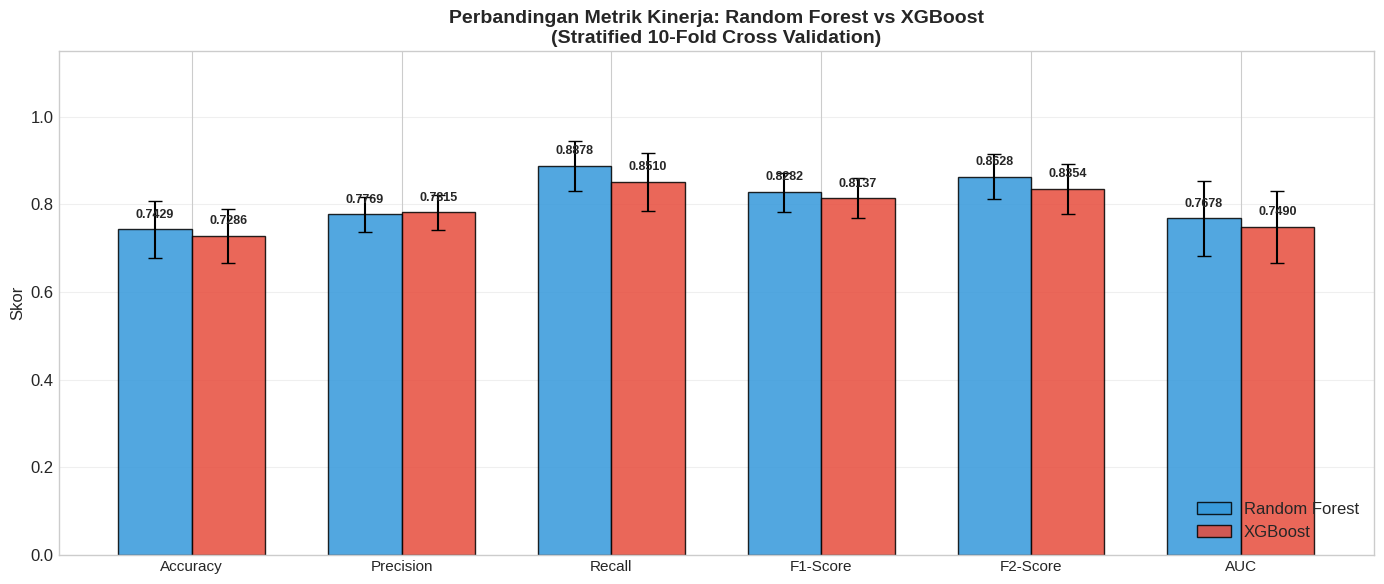

In [ ]:
# ============================================
# 11.2 Grouped Bar Chart Perbandingan Metrik
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_labels))
width = 0.35

rf_means = [np.mean(rf_metrics[m]) for m in metrics_list]
xgb_means = [np.mean(xgb_metrics[m]) for m in metrics_list]
rf_stds = [np.std(rf_metrics[m]) for m in metrics_list]
xgb_stds = [np.std(xgb_metrics[m]) for m in metrics_list]

bars1 = ax.bar(x - width/2, rf_means, width, yerr=rf_stds, label='Random Forest',
               color='#3498db', edgecolor='black', alpha=0.85, capsize=5)
bars2 = ax.bar(x + width/2, xgb_means, width, yerr=xgb_stds, label='XGBoost',
               color='#e74c3c', edgecolor='black', alpha=0.85, capsize=5)

ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Metrik Kinerja: Random Forest vs XGBoost\n(Stratified 10-Fold Cross Validation)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for bar, val in zip(bars1, rf_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, xgb_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


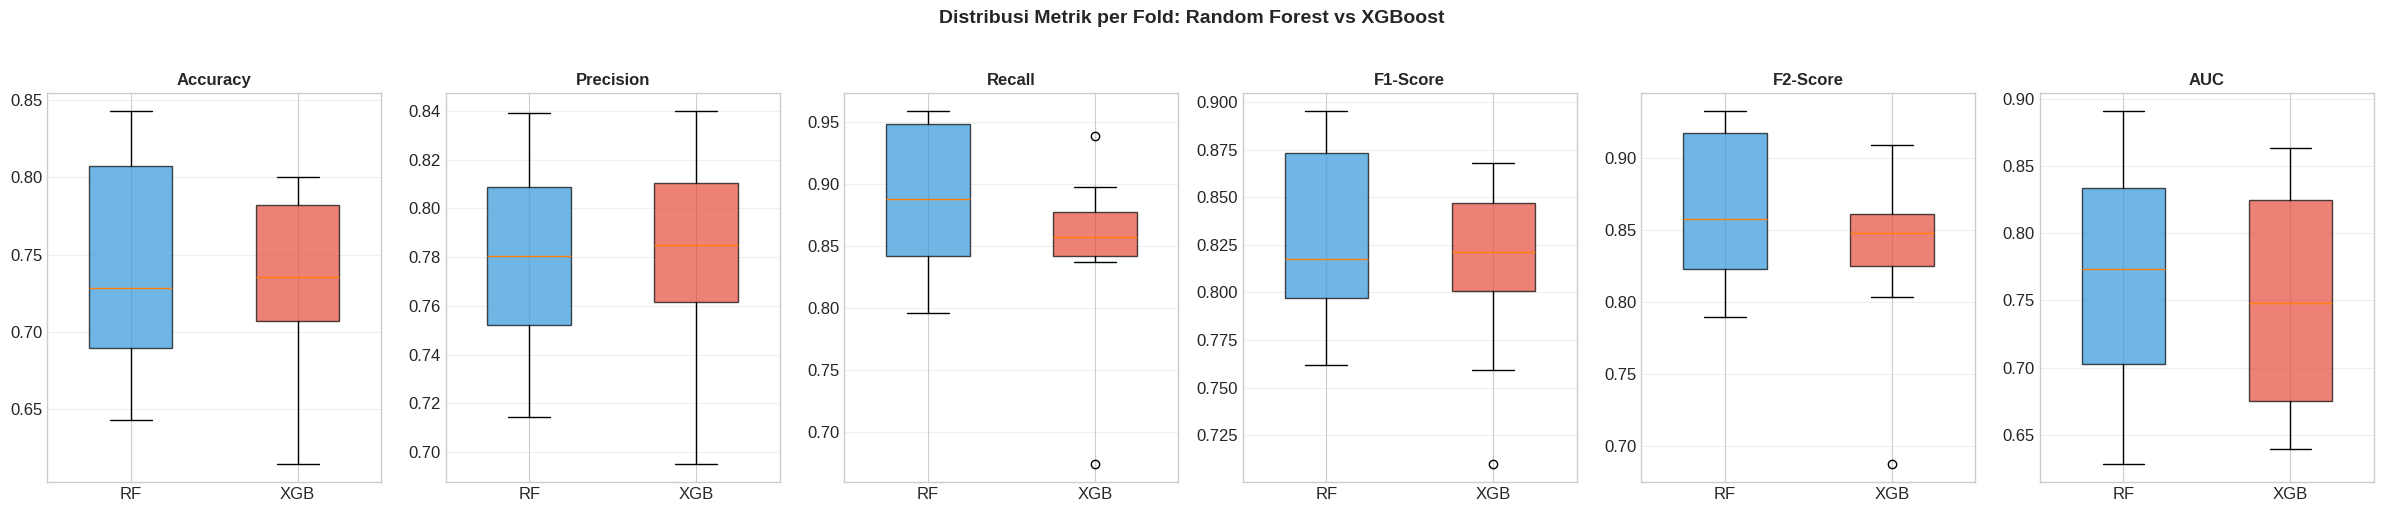

In [ ]:
# ============================================
# 11.3 Boxplot Distribusi Metrik per Fold
# ============================================
fig, axes = plt.subplots(1, len(metrics_list), figsize=(24, 5))

for i, (metric, label) in enumerate(zip(metrics_list, metrics_labels)):
    data_to_plot = [rf_metrics[metric], xgb_metrics[metric]]
    ax = axes[i] if len(metrics_list) > 1 else axes
    bp = ax.boxplot(data_to_plot, labels=['RF', 'XGB'], patch_artist=True,
                     widths=0.5)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.7)
        box.set_edgecolor('black')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Metrik per Fold: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 12. Analisis Feature Importance - Random Forest

Feature importance pada Random Forest dihitung berdasarkan **Mean Decrease in Impurity (MDI)**, yaitu seberapa besar kontribusi rata-rata setiap fitur dalam mengurangi impurity (Gini) di seluruh pohon dalam forest.


📊 Menghitung rata-rata Feature Importance dari 10-Fold (Random Forest)...


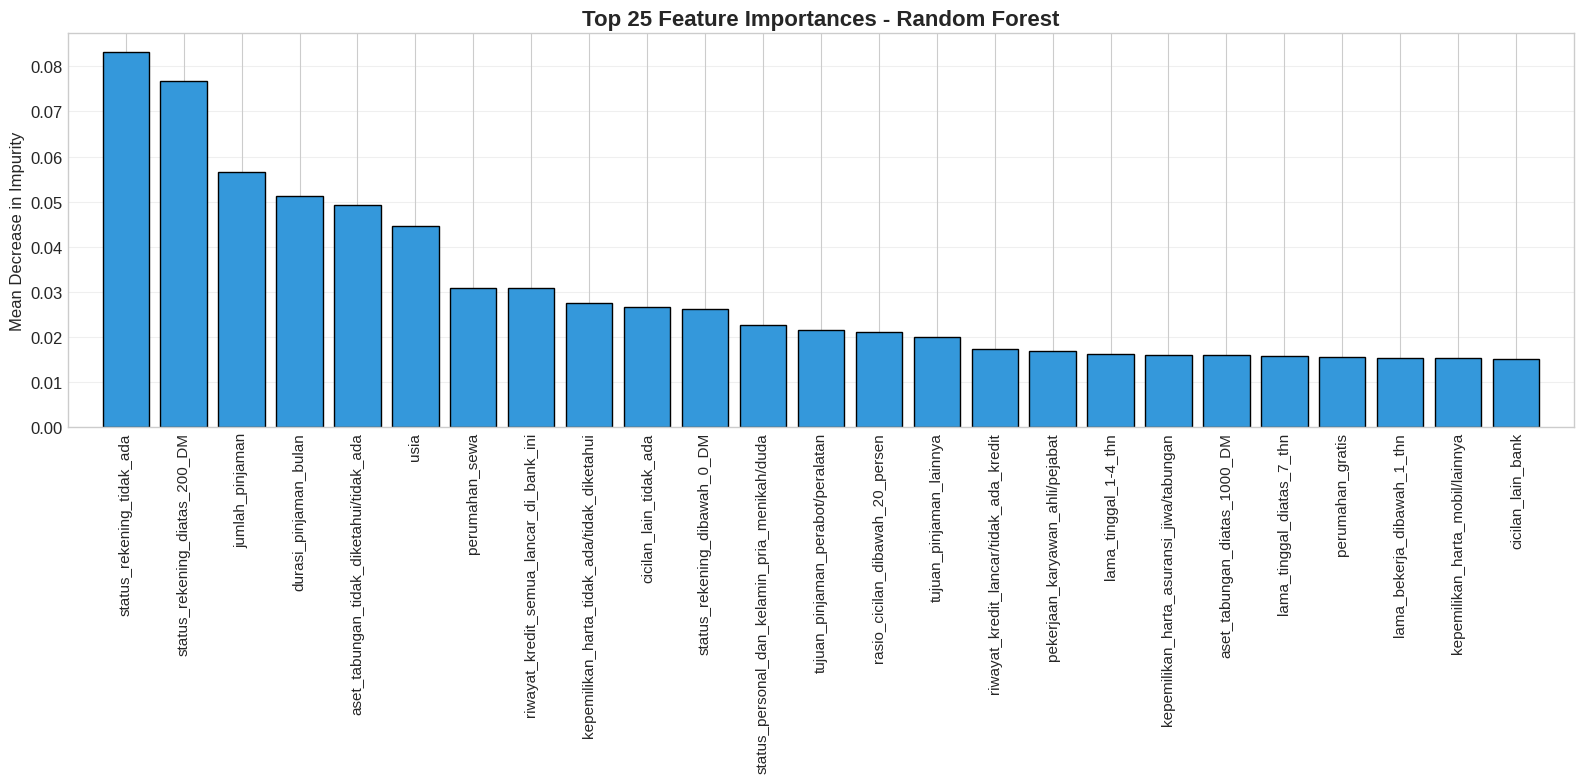

In [ ]:
# Feature Importance dipindahkan ke atas (Bagian 8.5)
# ============================================
# 12. Feature Importance - Random Forest
# ============================================
import numpy as np
import matplotlib.pyplot as plt

print("📊 Menghitung rata-rata Feature Importance dari 10-Fold (Random Forest)...")
rf_avg_importance = np.mean(rf_all_importances, axis=0)
indices_rf = np.argsort(rf_avg_importance)[::-1]

# Batasi hanya mengambil Top 25 fitur agar tidak tumpang tindih
TOP_N = min(25, len(feature_names))
top_indices_rf = indices_rf[:TOP_N]

plt.figure(figsize=(16, 8))
plt.title(f"Top {TOP_N} Feature Importances - Random Forest", fontsize=16, fontweight='bold')
plt.bar(range(TOP_N), rf_avg_importance[top_indices_rf], color="#3498db", align="center", edgecolor='black')
plt.xticks(range(TOP_N), [feature_names[i] for i in top_indices_rf], rotation=90, fontsize=11)
plt.xlim([-1, TOP_N])
plt.ylabel("Mean Decrease in Impurity", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Analisis Feature Importance - XGBoost

Feature importance pada XGBoost dihitung berdasarkan **gain**, yaitu rata-rata peningkatan performa (pengurangan loss) yang dihasilkan oleh fitur tersebut setiap kali digunakan untuk splitting.


📊 Menghitung rata-rata Feature Importance dari 10-Fold (XGBoost)...


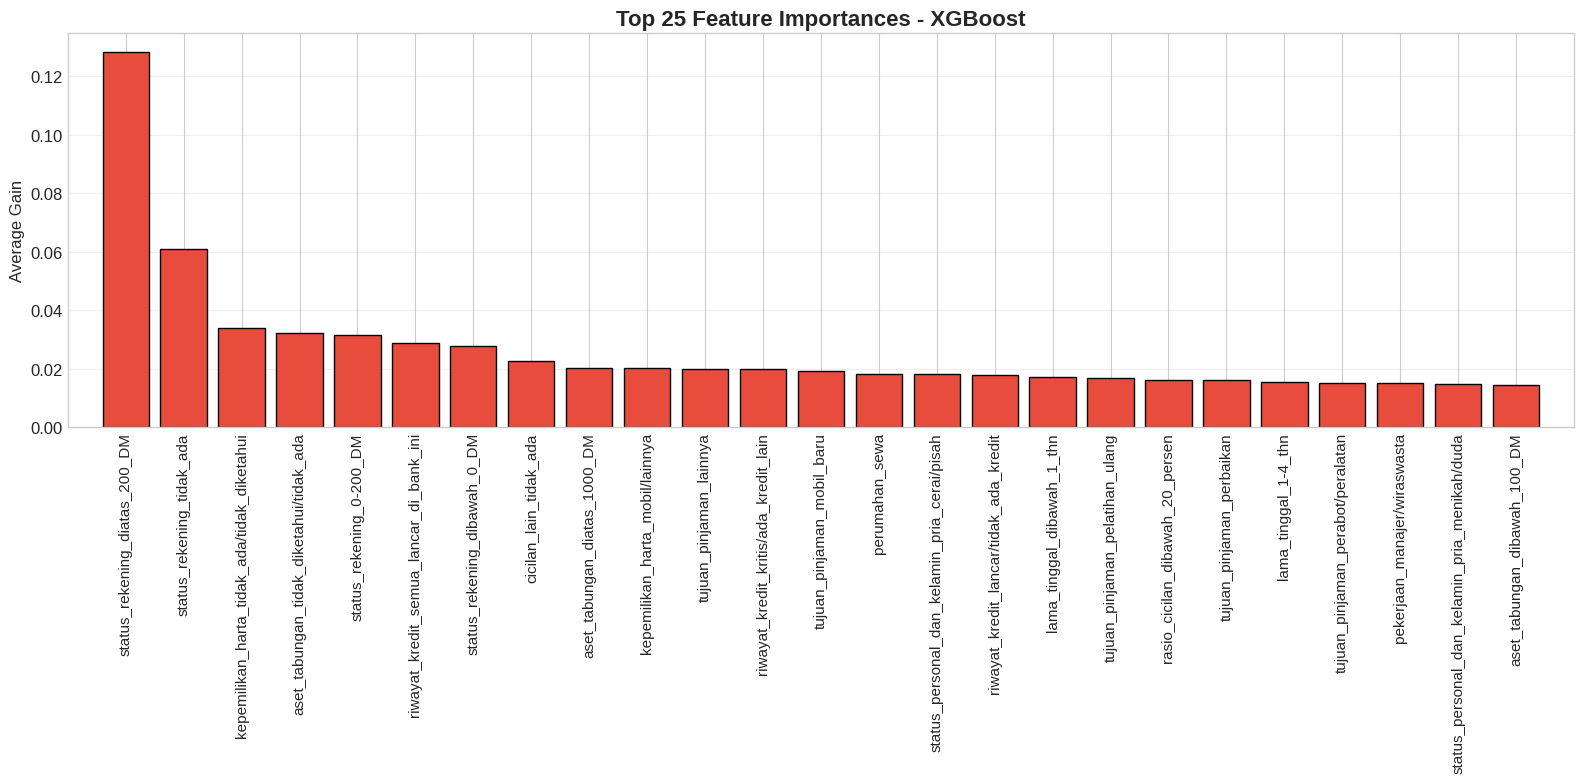

In [ ]:
# ============================================
# 13. Feature Importance - XGBoost
# ============================================
import numpy as np
import matplotlib.pyplot as plt

print("📊 Menghitung rata-rata Feature Importance dari 10-Fold (XGBoost)...")
xgb_avg_importance = np.mean(xgb_all_importances, axis=0)
indices_xgb = np.argsort(xgb_avg_importance)[::-1]

# Batasi hanya mengambil Top 25 fitur agar tidak tumpang tindih
TOP_N = min(25, len(feature_names))
top_indices_xgb = indices_xgb[:TOP_N]

plt.figure(figsize=(16, 8))
plt.title(f"Top {TOP_N} Feature Importances - XGBoost", fontsize=16, fontweight='bold')
plt.bar(range(TOP_N), xgb_avg_importance[top_indices_xgb], color="#e74c3c", align="center", edgecolor='black')
plt.xticks(range(TOP_N), [feature_names[i] for i in top_indices_xgb], rotation=90, fontsize=11)
plt.xlim([-1, TOP_N])
plt.ylabel("Average Gain", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Perbandingan Feature Importance Kedua Model

Membandingkan ranking feature importance dari Random Forest dan XGBoost secara side-by-side untuk mengidentifikasi fitur yang konsisten penting di kedua model.


📊 PERBANDINGAN RANKING FEATURE IMPORTANCE
                                                      Fitur  RF Rank  RF Importance  XGB Rank  XGB Importance  Selisih Rank
                                  status_rekening_tidak_ada        1       0.083146         2        0.060859             1
                              status_rekening_diatas_200_DM        2       0.076635         1        0.128168             1
                                            jumlah_pinjaman        3       0.056564        43        0.010657            40
                                      durasi_pinjaman_bulan        4       0.051239        30        0.013727            26
                    aset_tabungan_tidak_diketahui/tidak_ada        5       0.049227         4        0.032347             1
                                                       usia        6       0.044521        49        0.009439            43
                                             perumahan_sewa        7       0.030868       

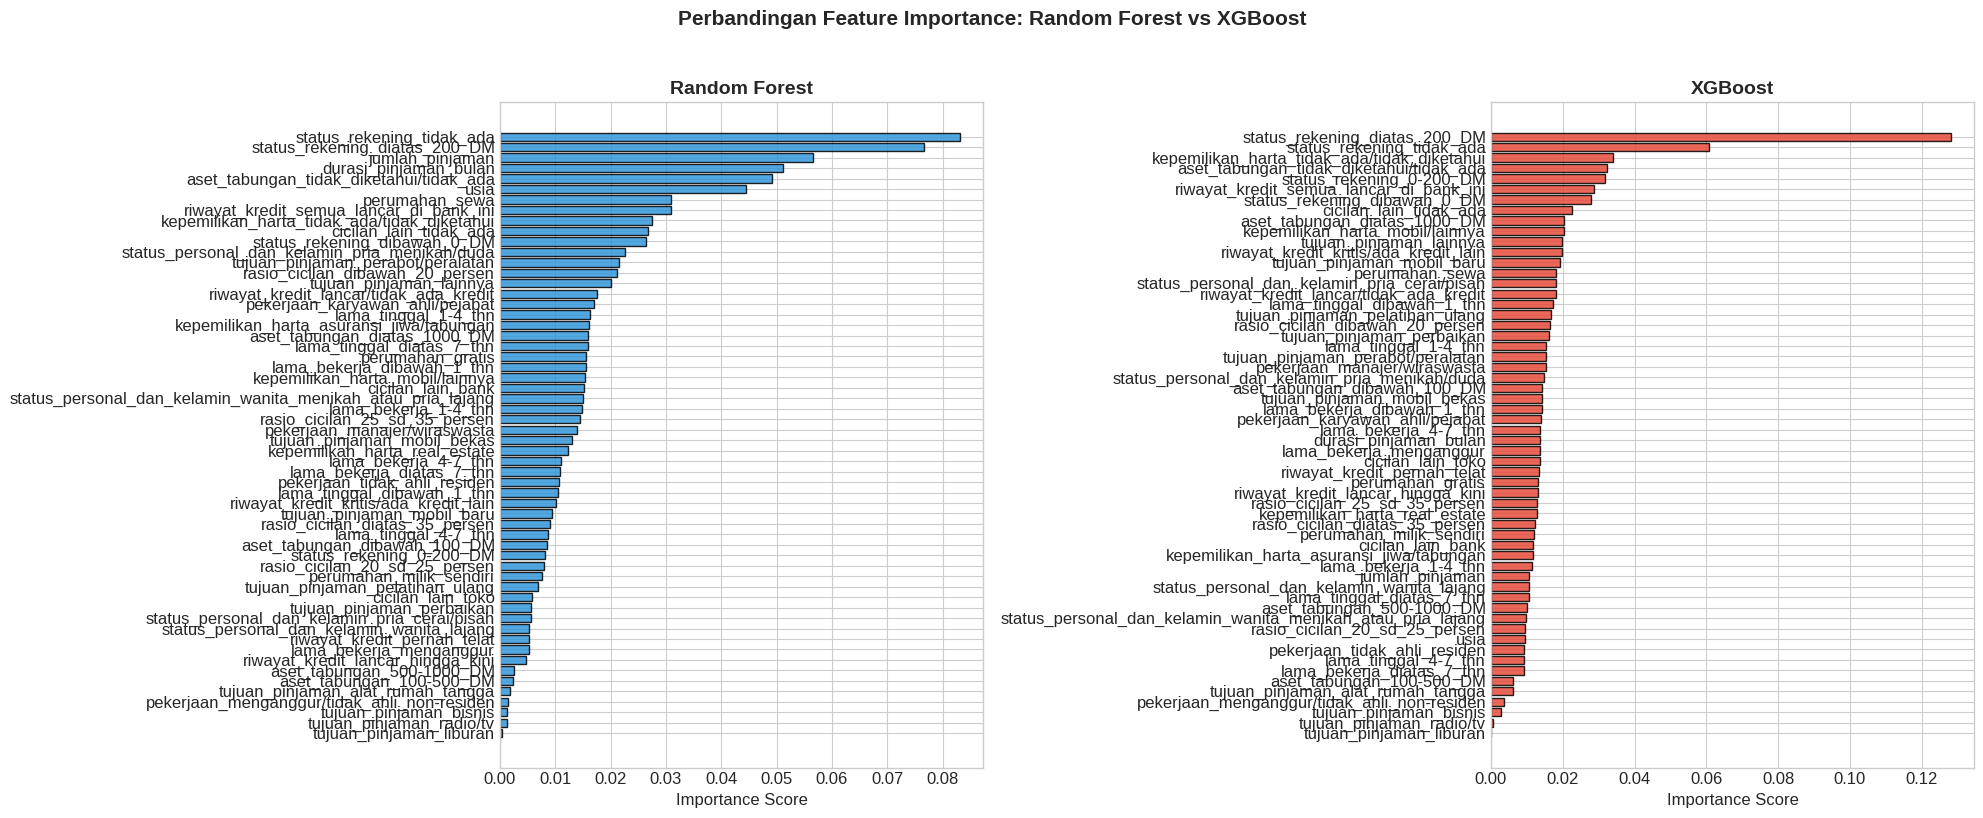


🔑 Top 5 Fitur Random Forest  : {'status_rekening_tidak_ada', 'durasi_pinjaman_bulan', 'aset_tabungan_tidak_diketahui/tidak_ada', 'status_rekening_diatas_200_DM', 'jumlah_pinjaman'}
🔑 Top 5 Fitur XGBoost        : {'status_rekening_tidak_ada', 'status_rekening_0-200_DM', 'aset_tabungan_tidak_diketahui/tidak_ada', 'status_rekening_diatas_200_DM', 'kepemilikan_harta_tidak_ada/tidak_diketahui'}
✅ Fitur Konsisten Penting     : {'status_rekening_tidak_ada', 'status_rekening_diatas_200_DM', 'aset_tabungan_tidak_diketahui/tidak_ada'}


In [ ]:
# ============================================
# 14. Perbandingan Feature Importance
# ============================================
print("📊 PERBANDINGAN RANKING FEATURE IMPORTANCE")
print("=" * 70)

# Buat tabel ranking perbandingan
ranking_comparison = pd.DataFrame({
    'Fitur': feature_names,
    'RF Importance': rf_avg_importance,
    'XGB Importance': xgb_avg_importance
})

# Hitung ranking
ranking_comparison['RF Rank'] = ranking_comparison['RF Importance'].rank(ascending=False).astype(int)
ranking_comparison['XGB Rank'] = ranking_comparison['XGB Importance'].rank(ascending=False).astype(int)
ranking_comparison['Selisih Rank'] = abs(ranking_comparison['RF Rank'] - ranking_comparison['XGB Rank'])
ranking_comparison = ranking_comparison.sort_values('RF Rank')

print(ranking_comparison[['Fitur', 'RF Rank', 'RF Importance', 'XGB Rank', 'XGB Importance', 'Selisih Rank']].to_string(index=False))

# Visualisasi side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest
rf_sorted = ranking_comparison.sort_values('RF Importance', ascending=True)
axes[0].barh(rf_sorted['Fitur'], rf_sorted['RF Importance'],
             color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_sorted = ranking_comparison.sort_values('XGB Importance', ascending=True)
axes[1].barh(xgb_sorted['Fitur'], xgb_sorted['XGB Importance'],
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Perbandingan Feature Importance: Random Forest vs XGBoost',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Fitur konsisten penting (top 5 di kedua model)
rf_top5 = set(ranking_comparison.nsmallest(5, 'RF Rank')['Fitur'])
xgb_top5 = set(ranking_comparison.nsmallest(5, 'XGB Rank')['Fitur'])
consistent_top = rf_top5.intersection(xgb_top5)

print(f"\n🔑 Top 5 Fitur Random Forest  : {rf_top5}")
print(f"🔑 Top 5 Fitur XGBoost        : {xgb_top5}")
print(f"✅ Fitur Konsisten Penting     : {consistent_top if consistent_top else 'Tidak ada'}")


## 15. Visualisasi Confusion Matrix Kedua Model

Confusion matrix menunjukkan distribusi prediksi benar dan salah untuk setiap kelas, membantu mengidentifikasi tipe kesalahan yang paling sering terjadi di masing-masing model.


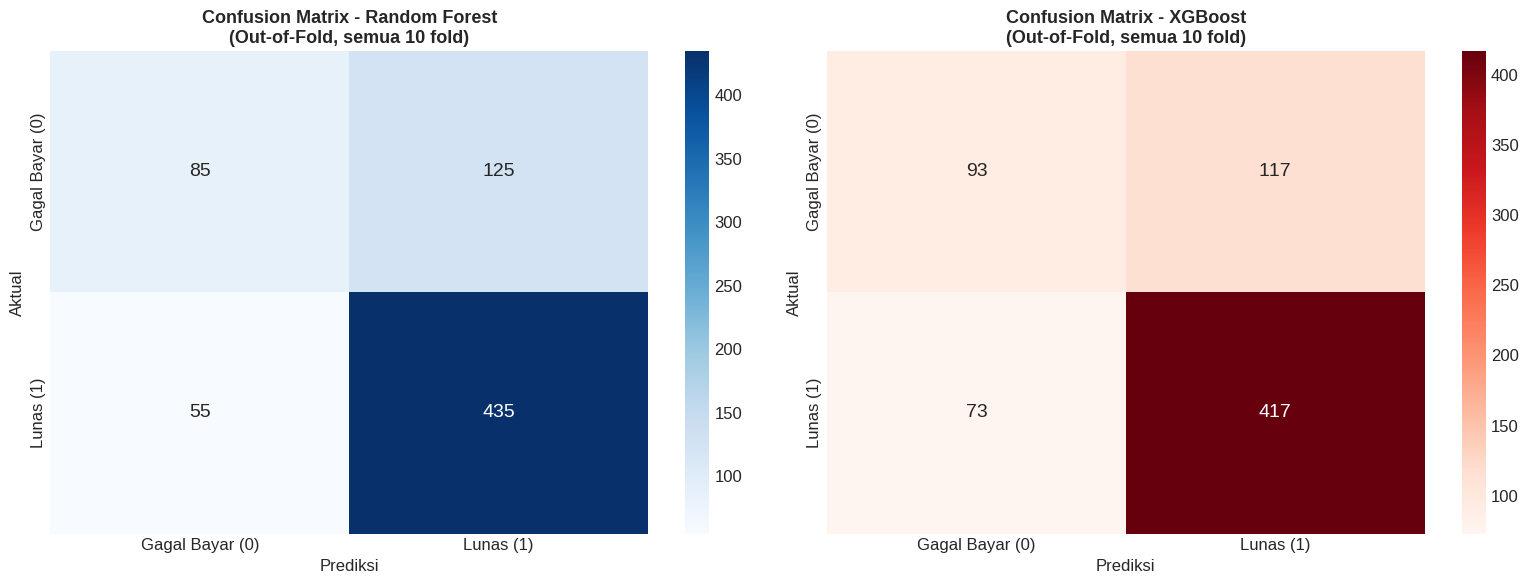


📊 Detail Confusion Matrix (OOF — semua fold digabung):

  Random Forest:
    True Negative  (TN) : 85 → Benar prediksi Gagal Bayar
    True Positive  (TP) : 435 → Benar prediksi Lunas
    False Positive (FP) : 125 → Salah prediksi Lunas (padahal Gagal Bayar)
    False Negative (FN) : 55 → Salah prediksi Gagal Bayar (padahal Lunas)

  XGBoost:
    True Negative  (TN) : 93 → Benar prediksi Gagal Bayar
    True Positive  (TP) : 417 → Benar prediksi Lunas
    False Positive (FP) : 117 → Salah prediksi Lunas (padahal Gagal Bayar)
    False Negative (FN) : 73 → Salah prediksi Gagal Bayar (padahal Lunas)

💰 Estimasi Kerugian Finansial (OOF — asumsi konsisten):
   FP: (1 - recovery_rate) × loan = 23,129/kasus
   FN: profit_margin × loan       = 1,652/kasus

  Random Forest:
    FP (diprediksi Lunas, nyatanya Gagal Bayar) : 125 → 2,891,175
    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : 55 → 90,866
    Total estimasi kerugian                      : 2,982,040

  XGBoost:
    FP (diprediksi L

In [ ]:
# ============================================
# 15. Confusion Matrix Kedua Model (Out-of-Fold)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix - Random Forest (OOF)
cm_rf = confusion_matrix(rf_oof_y_true, rf_oof_y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Random Forest\n(Out-of-Fold, semua 10 fold)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Aktual', fontsize=12)
axes[0].set_xlabel('Prediksi', fontsize=12)

# Confusion Matrix - XGBoost (OOF)
cm_xgb = confusion_matrix(xgb_oof_y_true, xgb_oof_y_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix - XGBoost\n(Out-of-Fold, semua 10 fold)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Aktual', fontsize=12)
axes[1].set_xlabel('Prediksi', fontsize=12)

plt.tight_layout()
plt.show()

# Detail angka
print("\n📊 Detail Confusion Matrix (OOF — semua fold digabung):")
print("=" * 60)
for name, cm in [('Random Forest', cm_rf), ('XGBoost', cm_xgb)]:
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  {name}:")
    print(f"    True Negative  (TN) : {tn:,} → Benar prediksi Gagal Bayar")
    print(f"    True Positive  (TP) : {tp:,} → Benar prediksi Lunas")
    print(f"    False Positive (FP) : {fp:,} → Salah prediksi Lunas (padahal Gagal Bayar)")
    print(f"    False Negative (FN) : {fn:,} → Salah prediksi Gagal Bayar (padahal Lunas)")

# Estimasi kerugian finansial (pakai asumsi yang sama dengan Step 9.1 & 10.1)
print("\n💰 Estimasi Kerugian Finansial (OOF — asumsi konsisten):")
print(f"   FP: (1 - recovery_rate) × loan = {loss_per_fp:,.0f}/kasus")
print(f"   FN: profit_margin × loan       = {cost_per_fn:,.0f}/kasus")

def estimate_loss_oof(model_name, y_true_list, y_pred_list):
    y_true_arr = np.array(y_true_list)
    y_pred_arr = np.array(y_pred_list)
    fp_count = int(((y_true_arr == 0) & (y_pred_arr == 1)).sum())
    fn_count = int(((y_true_arr == 1) & (y_pred_arr == 0)).sum())
    loss_fp = fp_count * loss_per_fp   # konsisten dengan Step 9.1
    loss_fn = fn_count * cost_per_fn   # konsisten dengan Step 9.1
    total   = loss_fp + loss_fn
    print(f"\n  {model_name}:")
    print(f"    FP (diprediksi Lunas, nyatanya Gagal Bayar) : {fp_count:,} → {loss_fp:,.0f}")
    print(f"    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : {fn_count:,} → {loss_fn:,.0f}")
    print(f"    Total estimasi kerugian                      : {total:,.0f}")

estimate_loss_oof('Random Forest', rf_oof_y_true, rf_oof_y_pred)
estimate_loss_oof('XGBoost',       xgb_oof_y_true, xgb_oof_y_pred)


## 16. Visualisasi ROC Curve dan AUC Score Kedua Model

ROC Curve (Receiver Operating Characteristic) menggambarkan kemampuan diskriminasi model pada berbagai threshold. **AUC** (Area Under Curve) yang lebih tinggi menunjukkan model yang lebih baik dalam membedakan kelas positif dan negatif.


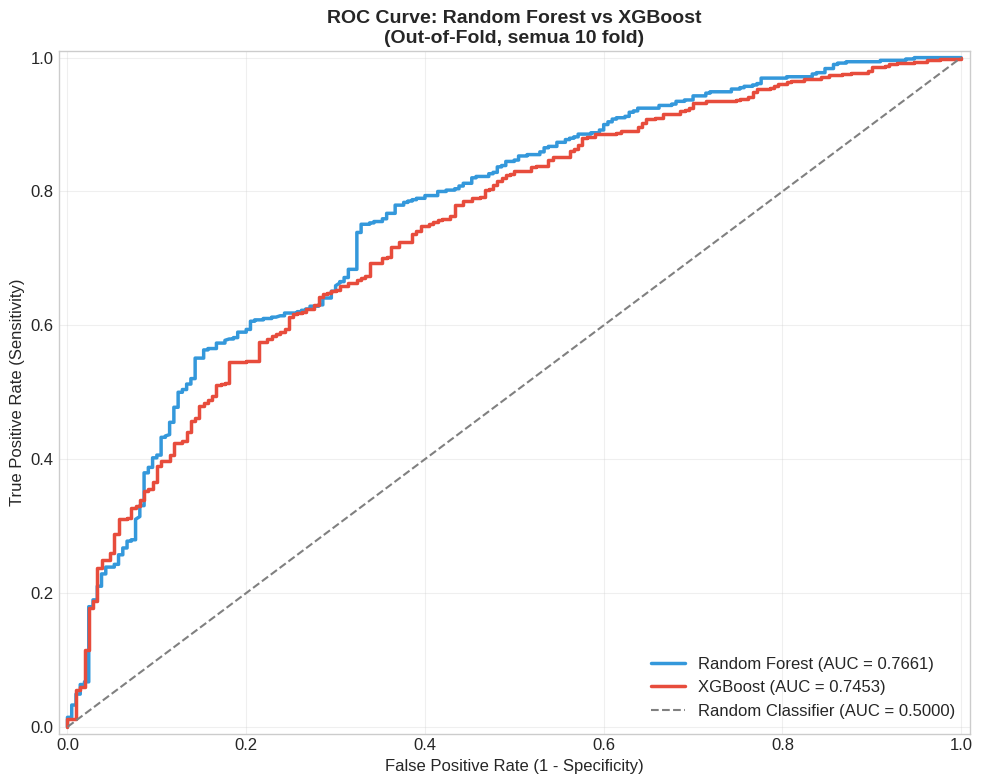


📊 Perbandingan AUC Score (OOF):
   Random Forest : 0.7661
   XGBoost       : 0.7453

   → Random Forest memiliki kemampuan diskriminasi lebih baik (+0.0208)


In [ ]:
# ============================================
# 16. ROC Curve dan AUC Score (Out-of-Fold)
# ============================================
fig, ax = plt.subplots(figsize=(10, 8))

# ROC - Random Forest (OOF)
fpr_rf, tpr_rf, _ = roc_curve(rf_oof_y_true, rf_oof_y_prob)
auc_rf = roc_auc_score(rf_oof_y_true, rf_oof_y_prob)
ax.plot(fpr_rf, tpr_rf, color='#3498db', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_rf:.4f})')

# ROC - XGBoost (OOF)
fpr_xgb, tpr_xgb, _ = roc_curve(xgb_oof_y_true, xgb_oof_y_prob)
auc_xgb = roc_auc_score(xgb_oof_y_true, xgb_oof_y_prob)
ax.plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2.5,
        label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Garis diagonal (random classifier)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5,
        label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve: Random Forest vs XGBoost\n(Out-of-Fold, semua 10 fold)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

print(f"\n📊 Perbandingan AUC Score (OOF):")
print(f"   Random Forest : {auc_rf:.4f}")
print(f"   XGBoost       : {auc_xgb:.4f}")
if auc_rf > auc_xgb:
    print(f"\n   → Random Forest memiliki kemampuan diskriminasi lebih baik (+{auc_rf-auc_xgb:.4f})")
else:
    print(f"\n   → XGBoost memiliki kemampuan diskriminasi lebih baik (+{auc_xgb-auc_rf:.4f})")


## 17. Uji Statistik Perbandingan Kinerja Model (Paired t-test)

Untuk menentukan apakah perbedaan kinerja antara kedua model **signifikan secara statistik**, dilakukan **Paired t-test** pada metrik dari setiap fold.

**Hipotesis:**
- **H₀ (Null):** Tidak ada perbedaan signifikan antara kinerja Random Forest dan XGBoost
- **H₁ (Alternatif):** Terdapat perbedaan signifikan antara kinerja Random Forest dan XGBoost
- **Significance Level (α):** 0.05


In [ ]:
# ============================================
# 17. Paired t-test
# ============================================
print("📊 UJI STATISTIK: PAIRED T-TEST")
print("=" * 70)
print(f"Significance Level (α) = 0.05")
print(f"Jumlah Fold            = {N_SPLITS}")
print()

alpha = 0.05
ttest_results = []

for metric, label in zip(metrics_list, metrics_labels):
    t_stat, p_value = ttest_rel(rf_metrics[metric], xgb_metrics[metric])
    significant = "Ya ✅" if p_value < alpha else "Tidak ❌"
    decision = "Tolak H₀" if p_value < alpha else "Gagal Tolak H₀"

    ttest_results.append({
        'Metrik': label,
        't-statistic': t_stat,
        'p-value': p_value,
        'Signifikan': significant,
        'Keputusan': decision
    })

ttest_df = pd.DataFrame(ttest_results)

for _, row in ttest_df.iterrows():
    print(f"  📌 {row['Metrik']}:")
    print(f"     t-statistic = {row['t-statistic']:.4f}")
    print(f"     p-value     = {row['p-value']:.6f}")
    print(f"     Signifikan  = {row['Signifikan']}")
    print(f"     Keputusan   = {row['Keputusan']}")
    print()

print("=" * 70)
print("\n📋 Ringkasan Paired t-test:")
print(ttest_df.to_string(index=False))


📊 UJI STATISTIK: PAIRED T-TEST
Significance Level (α) = 0.05
Jumlah Fold            = 10

  📌 Accuracy:
     t-statistic = 0.7798
     p-value     = 0.455518
     Signifikan  = Tidak ❌
     Keputusan   = Gagal Tolak H₀

  📌 Precision:
     t-statistic = -0.4574
     p-value     = 0.658223
     Signifikan  = Tidak ❌
     Keputusan   = Gagal Tolak H₀

  📌 Recall:
     t-statistic = 1.4886
     p-value     = 0.170783
     Signifikan  = Tidak ❌
     Keputusan   = Gagal Tolak H₀

  📌 F1-Score:
     t-statistic = 0.9834
     p-value     = 0.351125
     Signifikan  = Tidak ❌
     Keputusan   = Gagal Tolak H₀

  📌 F2-Score:
     t-statistic = 1.3504
     p-value     = 0.209850
     Signifikan  = Tidak ❌
     Keputusan   = Gagal Tolak H₀

  📌 AUC:
     t-statistic = 1.6107
     p-value     = 0.141715
     Signifikan  = Tidak ❌
     Keputusan   = Gagal Tolak H₀


📋 Ringkasan Paired t-test:
   Metrik  t-statistic  p-value Signifikan      Keputusan
 Accuracy     0.779813 0.455518    Tidak ❌ Gagal 

In [ ]:
# ============================================
# 20. Membuat & Menyimpan Model Final (model.pkl) — RF & XGBoost
# ============================================
import joblib
from sklearn.metrics import confusion_matrix

print("📊 RINGKASAN METRIK NESTED CV (RF vs XGBoost)")
print("=" * 70)

def summarize_metrics(metrics_dict, oof_y_true, oof_y_pred, params_repr):
    cm = confusion_matrix(oof_y_true, oof_y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'mean': {k: float(np.mean(v)) for k, v in metrics_dict.items()},
        'std': {k: float(np.std(v)) for k, v in metrics_dict.items()},
        'total_fp': int(fp),
        'total_fn': int(fn),
        'params_repr': params_repr,
    }

rf_summary  = summarize_metrics(rf_metrics,  rf_oof_y_true,  rf_oof_y_pred,  rf_params_repr)
xgb_summary = summarize_metrics(xgb_metrics, xgb_oof_y_true, xgb_oof_y_pred, xgb_params_repr)

for name, summ in [("Random Forest", rf_summary), ("XGBoost", xgb_summary)]:
    print(f"\n{name}:")
    for k, v in summ['mean'].items():
        print(f"   {k:<10}: {v:.4f} (± {summ['std'][k]:.4f})")
    print(f"   total_fp  : {summ['total_fp']:,}  |  total_fn: {summ['total_fn']:,}")

rf_f2_mean  = rf_summary['mean']['f2_score']
xgb_f2_mean = xgb_summary['mean']['f2_score']
best_model_name = "Random Forest" if rf_f2_mean >= xgb_f2_mean else "XGBoost"
print(f"\n🏆 Model dengan F2-Score tertinggi: {best_model_name} (info saja, KEDUA model tetap disimpan)")

# ============================================
# 20.1 Gunakan model terbaik dari Nested CV (tidak fit ulang)
# ============================================
print("\n✅ Menggunakan model dari fold dengan F2-Score tertinggi (tidak fit ulang):")
print(f"   RF  terbaik: fold dengan F2 = {rf_best_f2:.4f}")
print(f"   XGB terbaik: fold dengan F2 = {xgb_best_f2:.4f}")

# Gunakan langsung variabel yang telah ditentukan selama loop Nested CV
# rf_best_fold_model, rf_best_fold_ohe, rf_best_fold_feature_names
# xgb_best_fold_model, xgb_best_fold_ohe, xgb_best_fold_feature_names

# ============================================
# 20.3 Bungkus semua artefak & simpan ke model.pkl
# ============================================
model_artifact = {
    'models': {
        'Random Forest': rf_best_fold_model,
        'XGBoost': xgb_best_fold_model,
    },
    'metrics': {
        'Random Forest': rf_summary,
        'XGBoost': xgb_summary,
    },
    'best_model_name': best_model_name,
    # OHE encoder disimpan per-model karena berasal dari fold yang berbeda
    'ohe_encoder': {
        'Random Forest': rf_best_fold_ohe,
        'XGBoost': xgb_best_fold_ohe,
    },
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    # Impute values per-model (dari fold terbaik masing-masing)
    'num_impute_values': {
        'Random Forest': rf_best_fold_num_impute,
        'XGBoost': xgb_best_fold_num_impute,
    },
    'cat_impute_values': {
        'Random Forest': rf_best_fold_cat_impute,
        'XGBoost': xgb_best_fold_cat_impute,
    },
    'feature_names': {
        'Random Forest': rf_best_fold_feature_names,
        'XGBoost': xgb_best_fold_feature_names,
    },
    'target_map': {0: 'Gagal Bayar', 1: 'Lunas'},
}

joblib.dump(model_artifact, 'model.pkl')
print("\n💾 Model berhasil disimpan sebagai 'model.pkl' (berisi RF & XGBoost)")
print(f"   Ukuran file: {__import__('os').path.getsize('model.pkl') / 1024:.1f} KB")

📊 RINGKASAN METRIK NESTED CV (RF vs XGBoost)

Random Forest:
   accuracy  : 0.7429 (± 0.0652)
   precision : 0.7769 (± 0.0393)
   recall    : 0.8878 (± 0.0579)
   f1_score  : 0.8282 (± 0.0445)
   f2_score  : 0.8628 (± 0.0514)
   auc       : 0.7678 (± 0.0854)
   total_fp  : 125  |  total_fn: 55

XGBoost:
   accuracy  : 0.7286 (± 0.0613)
   precision : 0.7815 (± 0.0392)
   recall    : 0.8510 (± 0.0658)
   f1_score  : 0.8137 (± 0.0457)
   f2_score  : 0.8354 (± 0.0566)
   auc       : 0.7490 (± 0.0816)
   total_fp  : 117  |  total_fn: 73

🏆 Model dengan F2-Score tertinggi: Random Forest (info saja, KEDUA model tetap disimpan)

✅ Menggunakan model dari fold dengan F2-Score tertinggi (tidak fit ulang):
   RF  terbaik: fold dengan F2 = 0.9325
   XGB terbaik: fold dengan F2 = 0.9091

💾 Model berhasil disimpan sebagai 'model.pkl' (berisi RF & XGBoost)
   Ukuran file: 4251.1 KB


In [ ]:
# ============================================
# 13. Evaluasi pada Data Testing (30%)
# ============================================
print("🚀 Evaluasi Model Terbaik pada Data Testing (30%)")

# Preprocessing test set & train set full
X_train_final = X_train_full.copy()
X_test_final = X_test.copy()

# Imputasi
for col in num_cols:
    med = X_train_final[col].median()
    X_train_final[col] = X_train_final[col].fillna(med)
    X_test_final[col] = X_test_final[col].fillna(med)

for col in cat_cols:
    mod = X_train_final[col].mode()[0]
    X_train_final[col] = X_train_final[col].fillna(mod)
    X_test_final[col] = X_test_final[col].fillna(mod)

# OHE
ohe_final = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe_final.fit_transform(X_train_final[cat_cols])
X_test_ohe = ohe_final.transform(X_test_final[cat_cols])
ohe_names = ohe_final.get_feature_names_out(cat_cols).tolist()

X_train_proc = pd.concat([
    X_train_final[num_cols].reset_index(drop=True),
    pd.DataFrame(X_train_ohe, columns=ohe_names)
], axis=1)

X_test_proc = pd.concat([
    X_test_final[num_cols].reset_index(drop=True),
    pd.DataFrame(X_test_ohe, columns=ohe_names)
], axis=1)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train_full)

# Train RF Terbaik
rf_best = RandomForestClassifier(**rf_params_repr)
rf_best.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_best.predict(X_test_proc)
print("\n📋 Classification Report - Random Forest (Data Testing 30%):")
print(classification_report(y_test, y_pred_rf, target_names=['Gagal Bayar (0)', 'Lunas (1)']))

# Train XGB Terbaik
xgb_best = XGBClassifier(**xgb_params_repr)
xgb_best.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_best.predict(X_test_proc)
print("\n📋 Classification Report - XGBoost (Data Testing 30%):")
print(classification_report(y_test, y_pred_xgb, target_names=['Gagal Bayar (0)', 'Lunas (1)']))


🚀 Evaluasi Model Terbaik pada Data Testing (30%)

📋 Classification Report - Random Forest (Data Testing 30%):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.67      0.40      0.50        90
      Lunas (1)       0.78      0.91      0.84       210

       accuracy                           0.76       300
      macro avg       0.72      0.66      0.67       300
   weighted avg       0.75      0.76      0.74       300


📋 Classification Report - XGBoost (Data Testing 30%):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.64      0.49      0.55        90
      Lunas (1)       0.80      0.88      0.84       210

       accuracy                           0.76       300
      macro avg       0.72      0.68      0.70       300
   weighted avg       0.75      0.76      0.75       300



🔬 SHAP Interpretability (Global & Local)



🌟 A. SHAP - RANDOM FOREST


<Figure size 1400x1000 with 0 Axes>

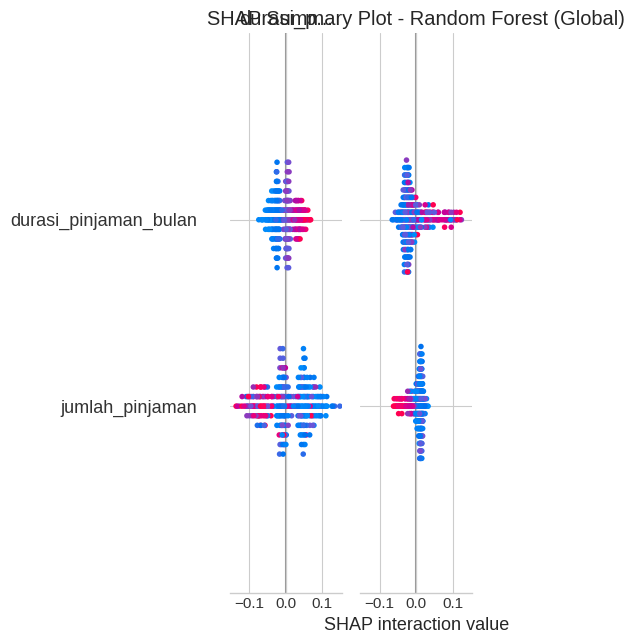


🔍 Keputusan RF untuk Nasabah 0:
  - Prediksi : Gagal Bayar (0)
  - Aktual   : Gagal Bayar (0)


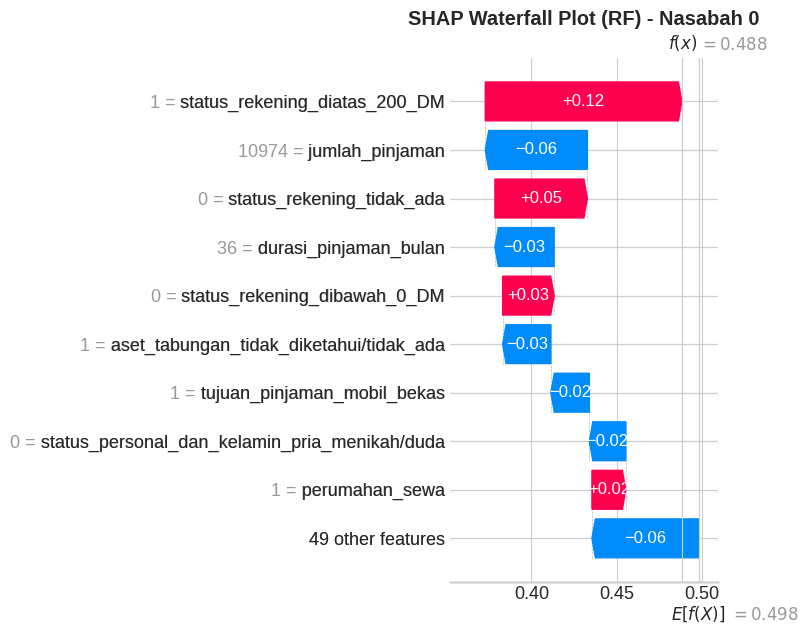


🌟 B. SHAP - XGBOOST


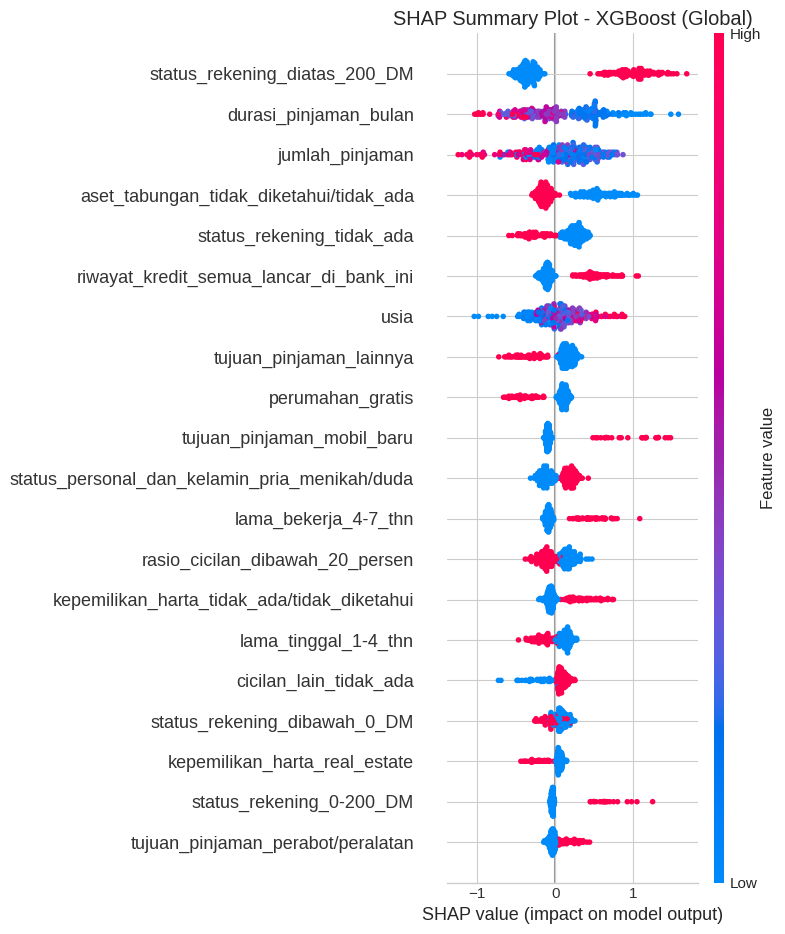


🔍 Keputusan XGBoost untuk Nasabah 0:
  - Prediksi : Gagal Bayar (0)
  - Aktual   : Gagal Bayar (0)


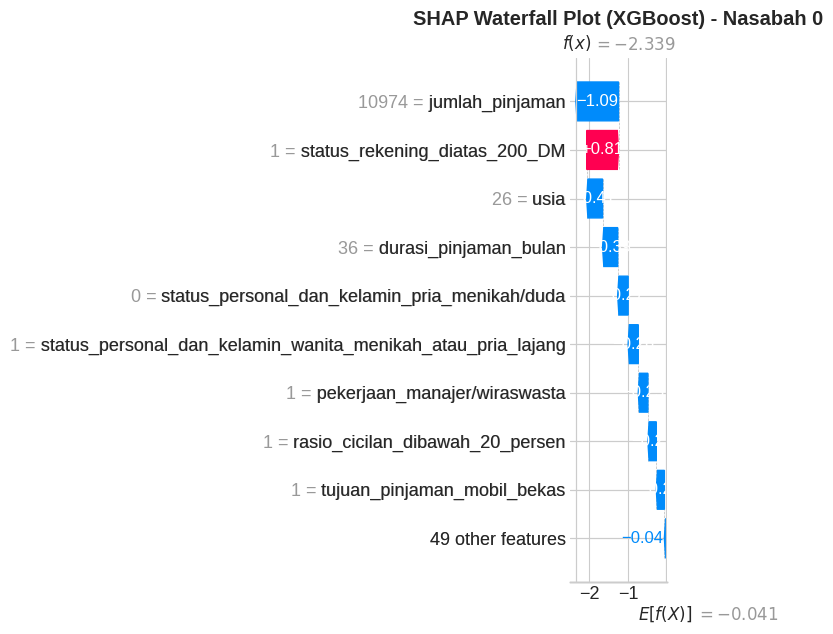

In [ ]:
# ============================================
# 14. SHAP Interpretability (Global & Local untuk RF & XGBoost)
# ============================================
import shap
import matplotlib.pyplot as plt
import numpy as np

print("🔬 SHAP Interpretability (Global & Local)")
shap.initjs()

indeks_nasabah = 0

# ==========================================
# A. SHAP UNTUK RANDOM FOREST
# ==========================================
print("\n" + "="*50)
print("🌟 A. SHAP - RANDOM FOREST")
print("="*50)

explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf_list = explainer_rf.shap_values(X_test_proc)
# RF multi-class → ambil kelas 1 (Lunas)
shap_values_rf = shap_values_rf_list[1] if isinstance(shap_values_rf_list, list) else shap_values_rf_list

# 1. Global Summary Plot
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_rf, X_test_proc, show=False)
plt.title('SHAP Summary Plot - Random Forest (Global)')
plt.tight_layout()
plt.show()

# 2. Local Waterfall Plot
print(f"\n🔍 Keputusan RF untuk Nasabah {indeks_nasabah}:")
print(f"  - Prediksi : {'Lunas (1)' if y_pred_rf[indeks_nasabah] == 1 else 'Gagal Bayar (0)'}")
print(f"  - Aktual   : {'Lunas (1)' if y_test.iloc[indeks_nasabah] == 1 else 'Gagal Bayar (0)'}")

# FIX: RF mengembalikan list → kita buat Explanation manual dari shap_values_rf_list[1]
expected_value_rf = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, (list, np.ndarray)) else explainer_rf.expected_value
shap_expl_rf_obj = explainer_rf(X_test_proc)  # shape: (n_samples, n_features, 2)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_expl_rf_obj[indeks_nasabah, :, 1], max_display=10, show=False)
plt.title(f"SHAP Waterfall Plot (RF) - Nasabah {indeks_nasabah}", fontweight='bold')
plt.tight_layout()
plt.show()


# ==========================================
# B. SHAP UNTUK XGBOOST
# ==========================================
print("\n" + "="*50)
print("🌟 B. SHAP - XGBOOST")
print("="*50)

explainer_xgb = shap.TreeExplainer(xgb_best)
shap_expl_xgb = explainer_xgb(X_test_proc)  # Langsung Explanation object
shap_values_xgb = explainer_xgb.shap_values(X_test_proc)

# 1. Global Summary Plot
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_xgb, X_test_proc, show=False)
plt.title('SHAP Summary Plot - XGBoost (Global)')
plt.tight_layout()
plt.show()

# 2. Local Waterfall Plot
print(f"\n🔍 Keputusan XGBoost untuk Nasabah {indeks_nasabah}:")
print(f"  - Prediksi : {'Lunas (1)' if y_pred_xgb[indeks_nasabah] == 1 else 'Gagal Bayar (0)'}")
print(f"  - Aktual   : {'Lunas (1)' if y_test.iloc[indeks_nasabah] == 1 else 'Gagal Bayar (0)'}")

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_expl_xgb[indeks_nasabah], max_display=10, show=False)
plt.title(f"SHAP Waterfall Plot (XGBoost) - Nasabah {indeks_nasabah}", fontweight='bold')
plt.tight_layout()
plt.show()